# Indiana Pines

1. Import dependencies

In [20]:
import random
import torch
import multiprocessing
import numpy as np
import re
import time

import torch.utils.data as data

from torch import nn
from lightning import Trainer
from dataclasses import asdict
from typing import Optional, Sequence
from pathlib import Path
from typing import Callable

from src.util.torch import resolve_torch_device
from src.util.hsi import (
    extract_patches,
    reduce_hsi_dim,
    preprocess_hsi,
    read_fixed_labels_mask_from_path,
    pu_bin_train_test_split_by_mask,
    PreProcessType,
    DimReductionType,
)
from src.data.indian_pines import load_indian_pines
from src.model.hsic import HyperSpectralImageClassifier
from src.visualization.plot import (
    plot_segmentation_comparison,
    plot_generic,
    plot_epoch_generic,
)
from src.data.dataset_decorator import UnlabeledDatasetDecorator, BinaryDatasetDecorator
from src.util.reporting import (
    create_model_name,
    report_run,
    read_report_to_show,
    lightning_metrics,
)
from src.util.scheduler import CosineLRSchedulerWrapper
from src.model.dbda import DBDA
from src.model.representative_datapoints_search import (
    RepresentativeDataPointsSearchAdapter,
    RepresentativeDataPointsSearch,
)
from src.definitions import RAW_DATA_FOLDER, REPORTS_FOLDER
from src.util.loss import PULoss

2. Prepare env

In [21]:
epoch_seconds = int(time.time())

log_dir = REPORTS_FOLDER / f"bin-dbda-k-medoids-pu-{epoch_seconds}"

mask_dir = Path(RAW_DATA_FOLDER / "mask" / "train-test-split")

In [22]:
learning_rate = 1e-3
weight_decay = 0
num_epochs = 10

In [23]:
batch_size = 64
patch_size = 9
target_dim = 75
target_class = 11

pre_process_type = PreProcessType.STANDARTIZATION
dim_reduction_type = DimReductionType.PCA

In [24]:
random_seed = 42

random.seed(random_seed)
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = resolve_torch_device()

In [25]:
torch.cuda.empty_cache()

In [26]:
torch.set_float32_matmul_precision("medium")

In [27]:
f"Device is {device}"

'Device is cuda'

3. Load dataset

In [28]:
image, labels = load_indian_pines()

image_h, image_w, image_c = image.shape

In [29]:
_, image = preprocess_hsi(image, pre_process_type)

In [30]:
_, target_dim, image = reduce_hsi_dim(
    image, target_dim, dim_reduction_type, device, random_seed
)

In [31]:
x, y = extract_patches(image, labels, patch_size=patch_size)

In [32]:
num_classes = len(np.unique(y))

f"Number of classes {num_classes}"

'Number of classes 17'

In [33]:
x_tensor = torch.tensor(x, dtype=torch.float32).permute(0, 3, 1, 2) 
y_tensor = torch.tensor(y, dtype=torch.long)

In [34]:
cpu_count = multiprocessing.cpu_count()

f"Setting num_workers to {cpu_count}"

'Setting num_workers to 24'

In [35]:
full_dataset = data.TensorDataset(x_tensor, y_tensor)

full_loader = data.DataLoader(
    BinaryDatasetDecorator(full_dataset, target_class),
    batch_size=batch_size,
    shuffle=False,
    num_workers=cpu_count,
    persistent_workers=True,
)
predict_loader = data.DataLoader(
    UnlabeledDatasetDecorator(full_dataset),
    batch_size=batch_size,
    num_workers=cpu_count,
    persistent_workers=True,
)

4. Train model

In [36]:
def extract_prediction(y_hat):
    return (torch.sigmoid(y_hat) > 0.5).to(dtype=torch.int)

In [37]:
from src.util.hsi import bin_train_test_split_by_mask


class IndianPinesDatapointsSearch(
    RepresentativeDataPointsSearchAdapter[HyperSpectralImageClassifier]
):
    target_class: int

    def __init__(self, target_class):
        super().__init__()

        self.target_class = target_class

    def get_run_params(
        self,
    ) -> Sequence[
        Callable[
            [], tuple[str, data.DataLoader, Optional[data.DataLoader], dict[str, float]]
        ]
    ]:
        params = {
            "num_epochs": num_epochs,
            "learning_rate": learning_rate,
            "t_initial": num_epochs,
            "weight_decay": weight_decay,
            "lr_min": learning_rate * 0.01,
            "warmup_lr_init": learning_rate * 0.01,
            "warmup_t": int(np.ceil(0.1 * num_epochs)),
        }

        return [
            self.create_run_params(id, path, params)
            for id, path in self.load_partitions_by_class(self.target_class)
        ]

    def init_model(self, params: dict[str, float]) -> HyperSpectralImageClassifier:
        positive_count = (y == self.target_class).sum()
        positive_prob = torch.tensor(positive_count / len(y), dtype=torch.float32)

        loss = PULoss(
            prior=positive_prob,
            nnpu=True,
            loss_fn=lambda x: torch.nn.functional.softplus(-x),
        )

        return HyperSpectralImageClassifier(
            DBDA(band=target_dim, classes=1, flatten_out=True),
            2,
            lr=params["learning_rate"],
            weight_decay=params["weight_decay"],
            loss_fun=loss,
            pred_extractor=extract_prediction,
            scheduler=lambda optimizer: CosineLRSchedulerWrapper(
                optimizer,
                t_initial=params["num_epochs"],
                lr_min=params["lr_min"],
                warmup_t=params["warmup_t"],
                warmup_lr_init=params["warmup_lr_init"],
            ),
        )

    def fit_model(
        self,
        model: HyperSpectralImageClassifier,
        loader: data.DataLoader,
        eval_loader: Optional[data.DataLoader],
        params: dict[str, float],
    ):
        trainer = Trainer(
            accelerator="auto",
            max_epochs=params["num_epochs"],
            enable_model_summary=False,
        )

        trainer.fit(model, loader, eval_loader)

        return [asdict(it) for it in model.val_metrics]

    def score_model(
        self, model: HyperSpectralImageClassifier
    ) -> list[dict[str, float]]:
        trainer = Trainer(accelerator="auto", max_epochs=0, enable_model_summary=False)

        return trainer.validate(model, full_loader)[0]

    def on_scored_model(
        self,
        id: str,
        params: dict[str, float],
        model: HyperSpectralImageClassifier,
        model_history: list[dict[str, float]],
        score: dict[str, float],
    ):
        trainer = Trainer(accelerator="auto", max_epochs=0, enable_model_summary=False)

        losses = [it["loss"].cpu() for it in model_history]
        f1s = [it["f1"].cpu() for it in model_history]
        plot_epoch_generic(
            losses, desc=f"Loss for class {self.target_class} ({id} examples)"
        )
        plot_epoch_generic(
            f1s, desc=f"F1 for class {self.target_class} ({id} examples)"
        )

        y_pred = trainer.predict(model, predict_loader)
        y_pred = torch.cat(y_pred, dim=0)
        y_pred = extract_prediction(y_pred)
        y_pred = y_pred.reshape(image_h, image_w)

        plot_segmentation_comparison(
            y.reshape(image_h, image_w) == self.target_class, y_pred.numpy()
        )

        model_name = create_model_name(f"indian_pines_bin", {target_class: id})
        model_category = "dbda"

        run_params = {
            **params,
            "batch_size": batch_size,
            "patch_size": patch_size,
            "target_dim": target_dim,
            "pre_process_type": str(pre_process_type),
            "dim_reduction_type": str(dim_reduction_type),
        }

        report_run(
            model_name=model_name,
            model_category=model_category,
            run_desc="New PU",
            run_params=run_params | model.get_params(),
            run_metrics=lightning_metrics(score),
        )

        read_report_to_show(model_name, sort_by_metric="f1")

    def load_partitions_by_class(self, clazz: int) -> list[tuple[str, Path]]:
        mask_arr = [
            (re.search(r"-(\d+)\.npy$", str(fn)).group(1), fn)
            for fn in mask_dir.glob(f"indian-pines-train-test-split-{clazz}-*.npy")
        ]

        return sorted(list(set(mask_arr)), key=lambda it: int(it[0]))

    def create_dataloader_from_mask_file(
        self, path: Path
    ) -> tuple[data.DataLoader, data.DataLoader]:
        mask = read_fixed_labels_mask_from_path(path)

        x_train, y_train, _, _ = pu_bin_train_test_split_by_mask(
            self.target_class, x, y, mask
        )

        x_train_tensor = torch.tensor(x_train, dtype=torch.float32).permute(0, 3, 1, 2)
        y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
        x_test_tensor = torch.tensor(x, dtype=torch.float32).permute(0, 3, 1, 2)
        y_test_tensor = torch.tensor(y == self.target_class, dtype=torch.float32)

        train_dataset = data.TensorDataset(x_train_tensor, y_train_tensor)
        test_dataset = data.TensorDataset(x_test_tensor, y_test_tensor)

        train_loader = data.DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            num_workers=cpu_count,
            persistent_workers=True,
        )
        test_loader = data.DataLoader(
            test_dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=cpu_count,
            persistent_workers=True,
        )

        return train_loader, test_loader

    def create_run_params(
        self, id: str, path: Path, params: dict[str, float]
    ) -> Callable[
        [], tuple[str, data.DataLoader, Optional[data.DataLoader], dict[str, float]]
    ]:
        def curryng():
            loader, eval_loader = self.create_dataloader_from_mask_file(path)

            return id, loader, eval_loader, params

        return curryng

  0%|          | 0/18 [00:00<?, ?it/s]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/melal/Workspace/hsi-classification-playground/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |          | 0/? [00:00<?, ?it/s]

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.8832342624664307
         val_f1              0.828471302986145
        val_kappa                   0.0
        val_loss            0.25162336230278015
  val_overall_accuracy              0.5
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


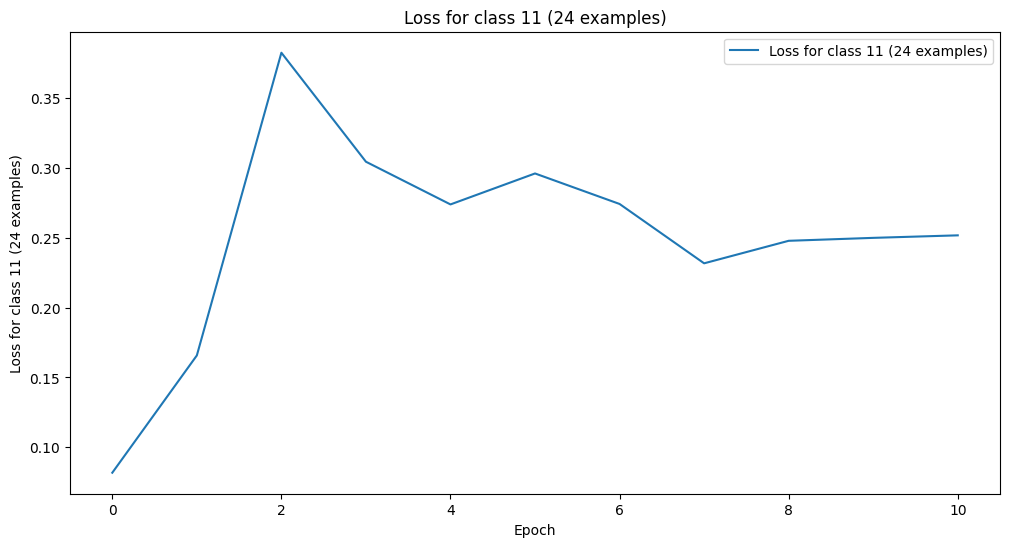

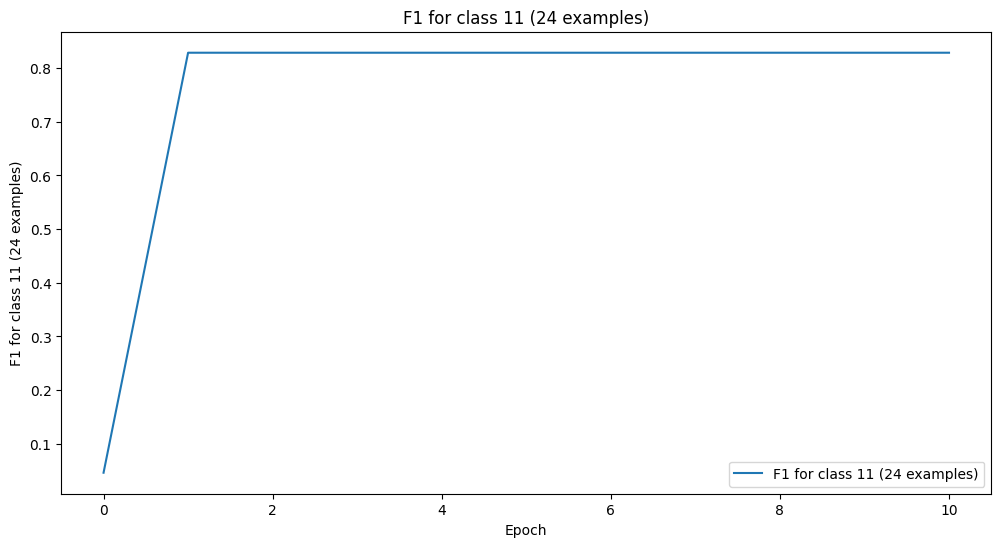

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

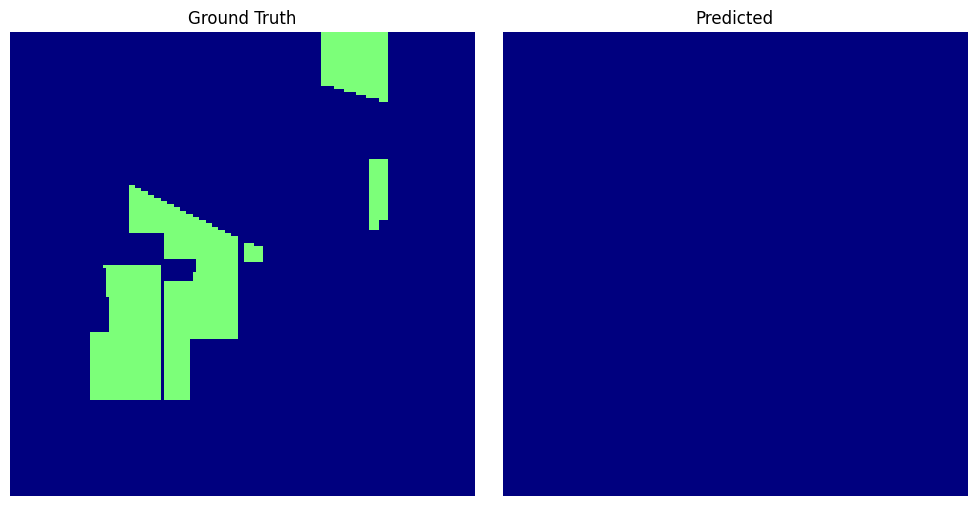

  6%|▌         | 1/18 [01:30<25:34, 90.26s/it, id=24, val_average_accuracy=0.883, val_f1=0.828, val_kappa=0, val_loss=0.252, val_overall_accuracy=0.5]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |          | 0/? [00:00<?, ?it/s]

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.8832342624664307
         val_f1              0.828471302986145
        val_kappa                   0.0
        val_loss            0.23948034644126892
  val_overall_accuracy              0.5
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


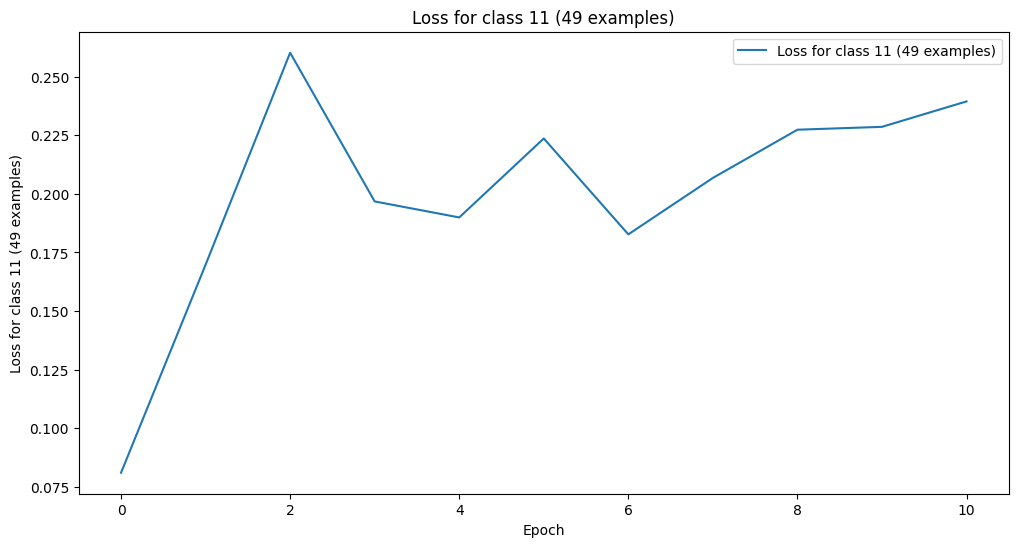

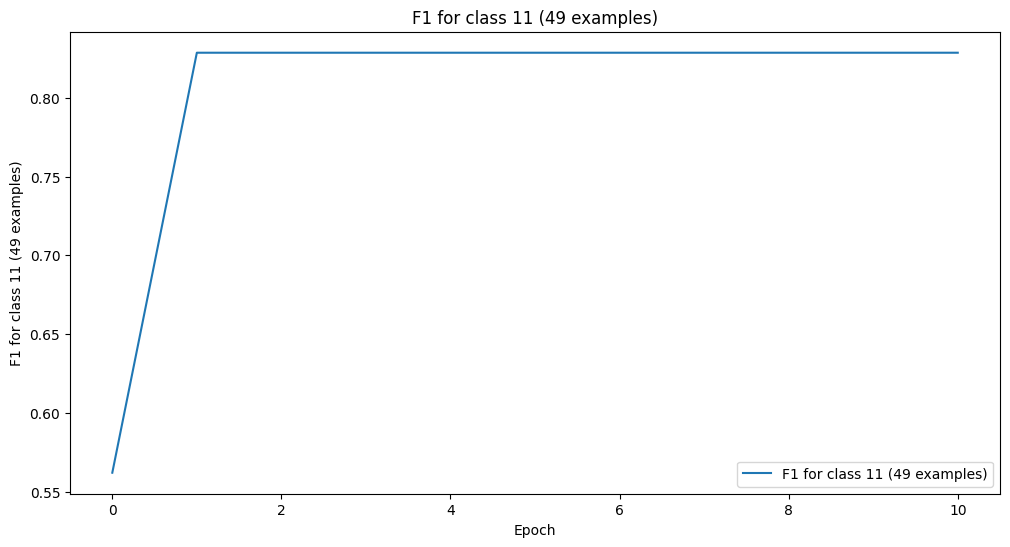

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

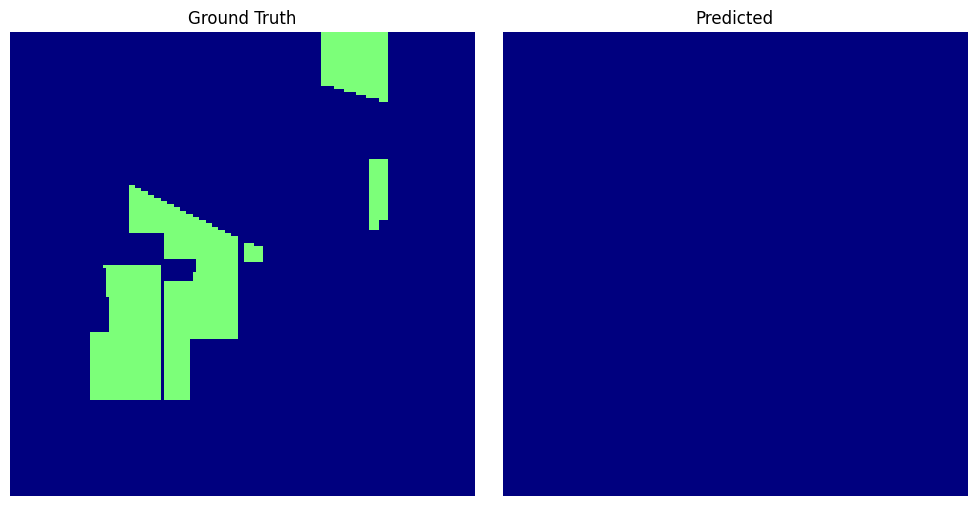

 11%|█         | 2/18 [02:59<23:54, 89.67s/it, id=49, val_average_accuracy=0.883, val_f1=0.828, val_kappa=0, val_loss=0.239, val_overall_accuracy=0.5]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |          | 0/? [00:00<?, ?it/s]

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.8832342624664307
         val_f1              0.828471302986145
        val_kappa                   0.0
        val_loss            0.1746339052915573
  val_overall_accuracy              0.5
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


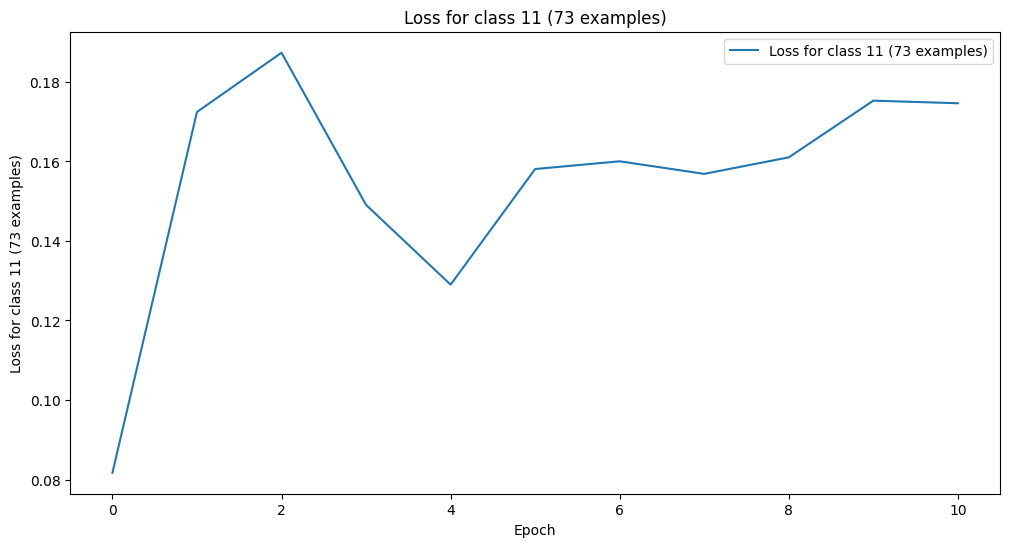

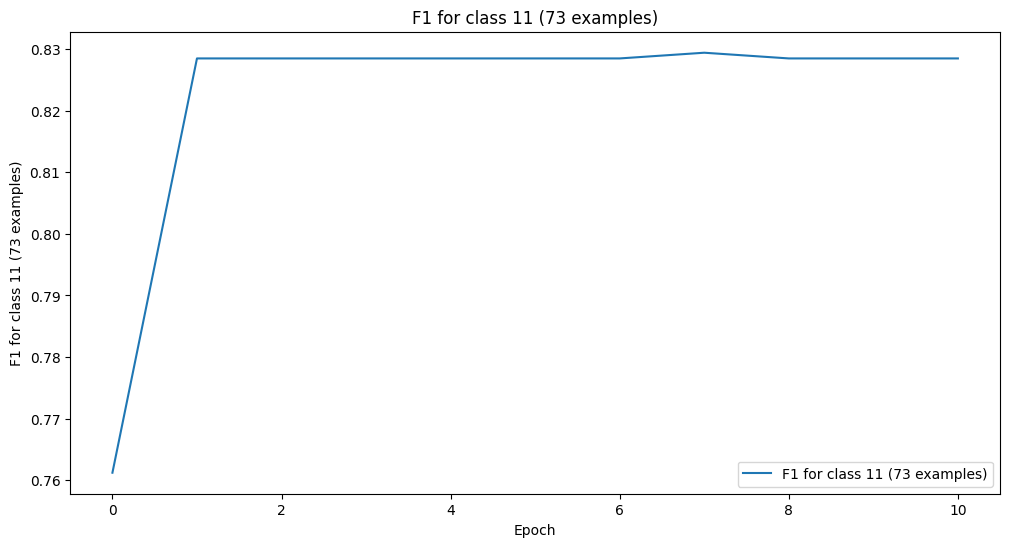

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

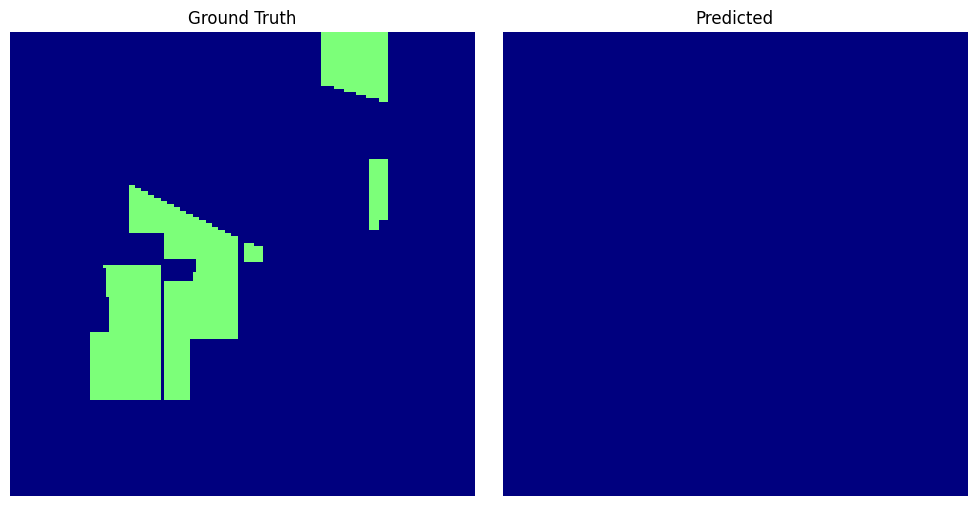

 17%|█▋        | 3/18 [04:28<22:20, 89.37s/it, id=73, val_average_accuracy=0.883, val_f1=0.828, val_kappa=0, val_loss=0.175, val_overall_accuracy=0.5]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |          | 0/? [00:00<?, ?it/s]

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.8832342624664307
         val_f1              0.828471302986145
        val_kappa                   0.0
        val_loss            0.13836956024169922
  val_overall_accuracy              0.5
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


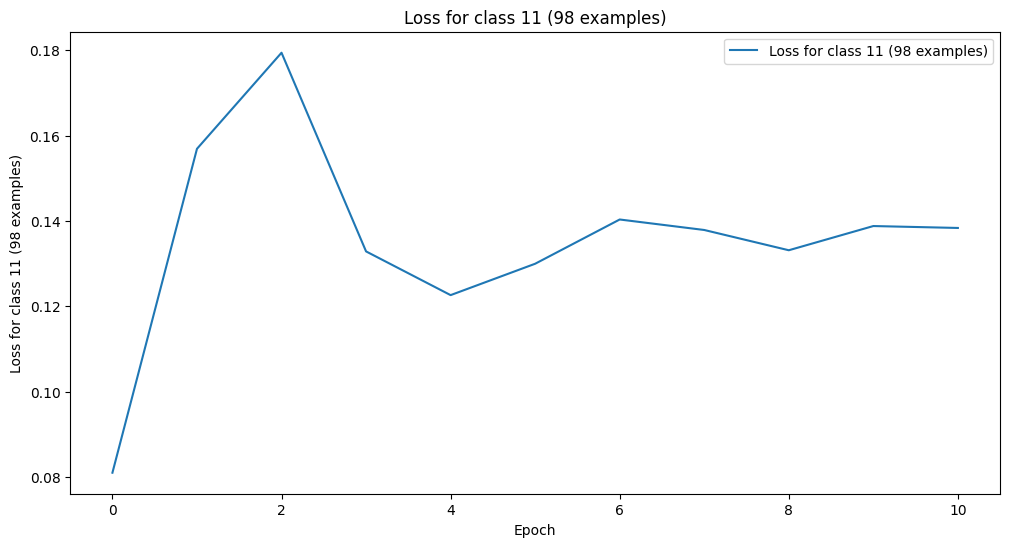

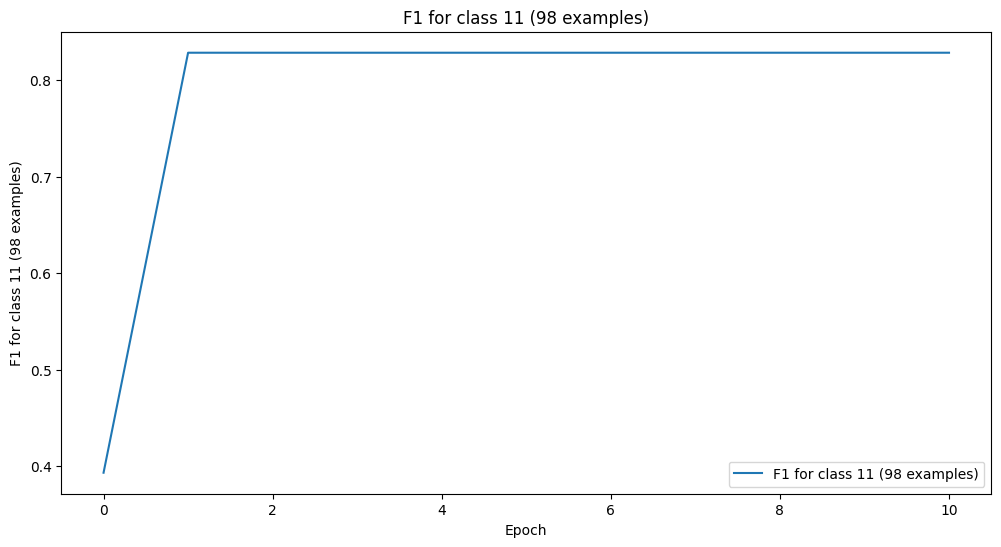

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

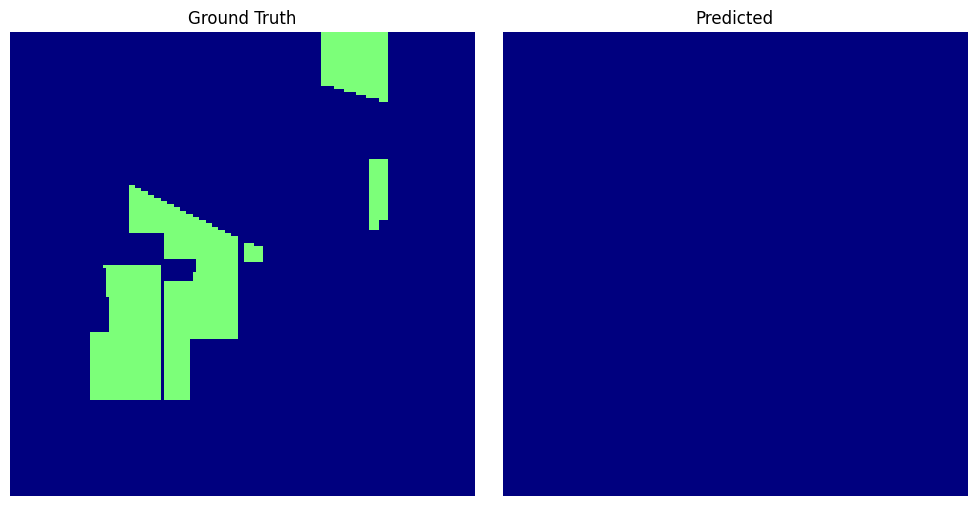

 22%|██▏       | 4/18 [05:55<20:40, 88.60s/it, id=98, val_average_accuracy=0.883, val_f1=0.828, val_kappa=0, val_loss=0.138, val_overall_accuracy=0.5]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |          | 0/? [00:00<?, ?it/s]

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.8832342624664307
         val_f1              0.828471302986145
        val_kappa                   0.0
        val_loss            0.11112409085035324
  val_overall_accuracy              0.5
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


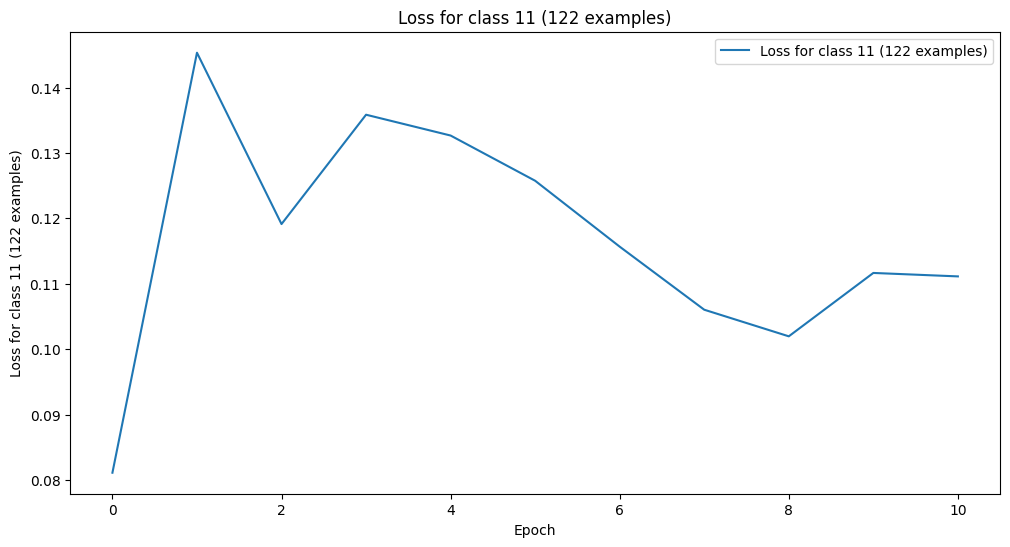

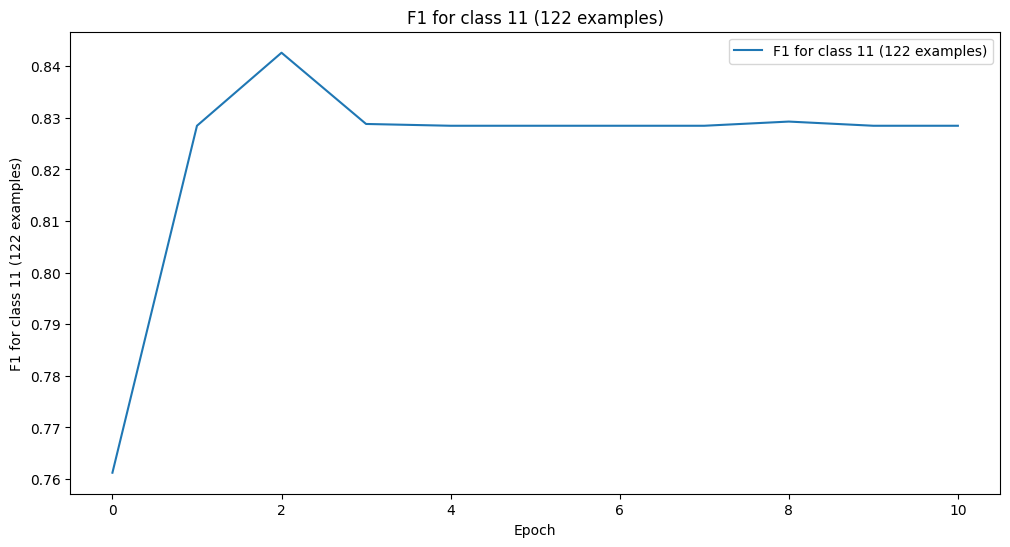

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

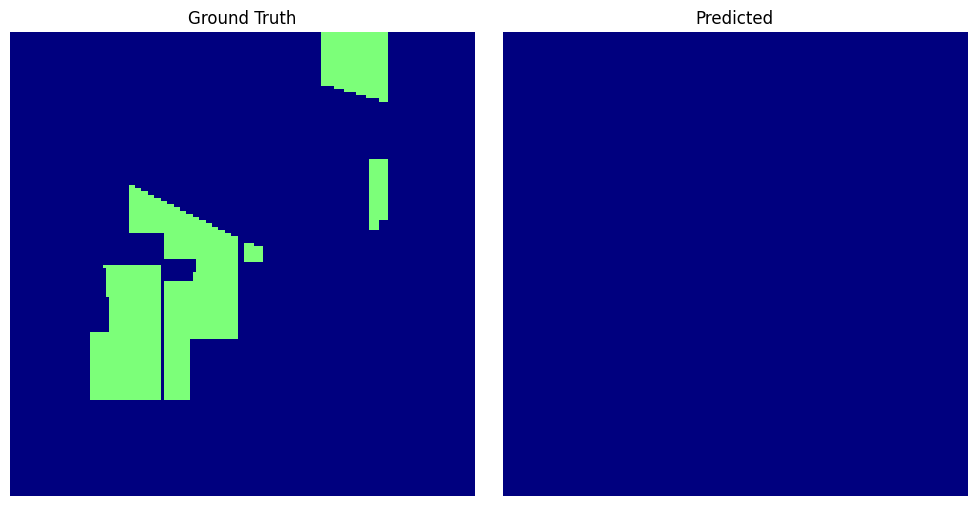

 28%|██▊       | 5/18 [07:26<19:19, 89.18s/it, id=122, val_average_accuracy=0.883, val_f1=0.828, val_kappa=0, val_loss=0.111, val_overall_accuracy=0.5]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |          | 0/? [00:00<?, ?it/s]

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.8832342624664307
         val_f1              0.828471302986145
        val_kappa                   0.0
        val_loss            0.1055871769785881
  val_overall_accuracy              0.5
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


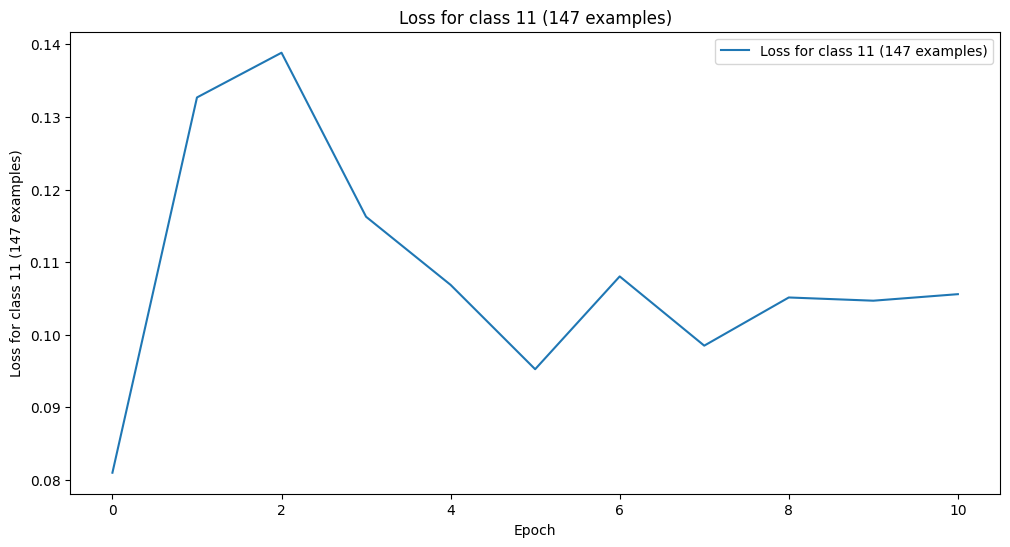

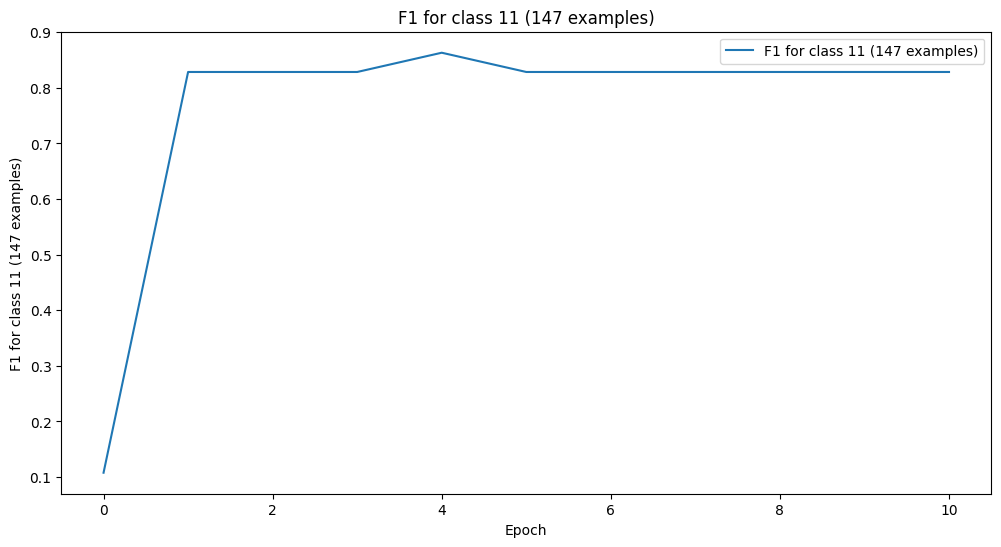

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

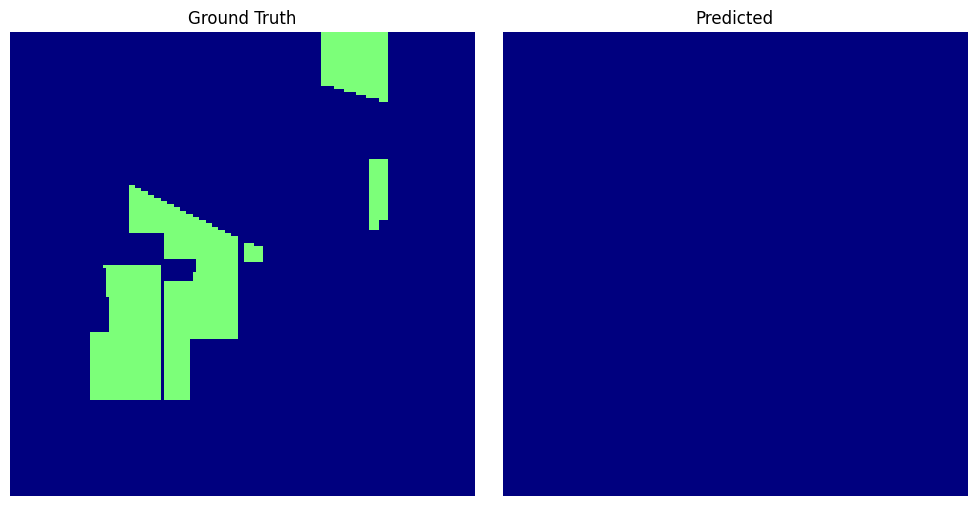

 33%|███▎      | 6/18 [08:54<17:46, 88.86s/it, id=147, val_average_accuracy=0.883, val_f1=0.828, val_kappa=0, val_loss=0.106, val_overall_accuracy=0.5]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |          | 0/? [00:00<?, ?it/s]

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.8836622834205627
         val_f1             0.8295125961303711
        val_kappa          0.006457805633544922
        val_loss            0.10092370212078094
  val_overall_accuracy      0.5018330216407776
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


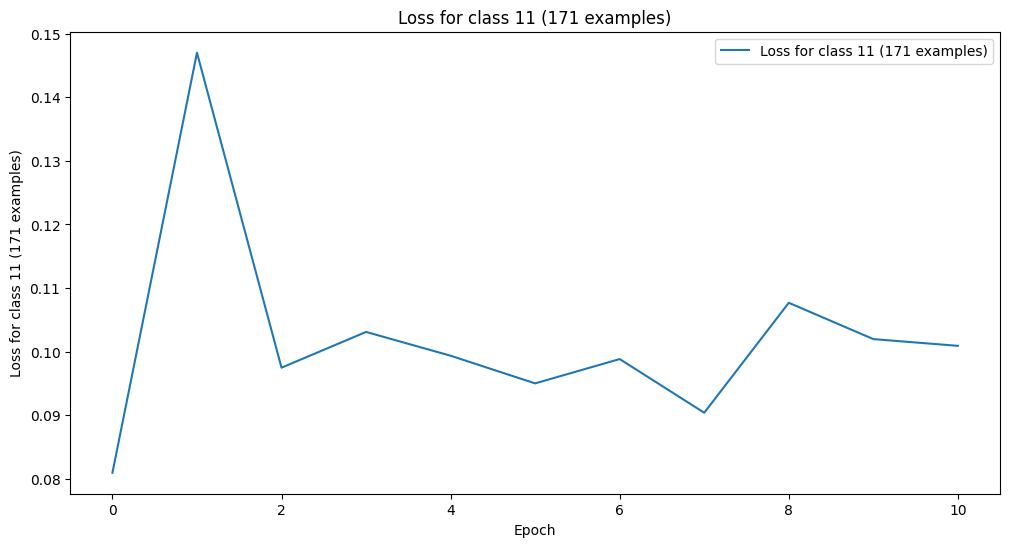

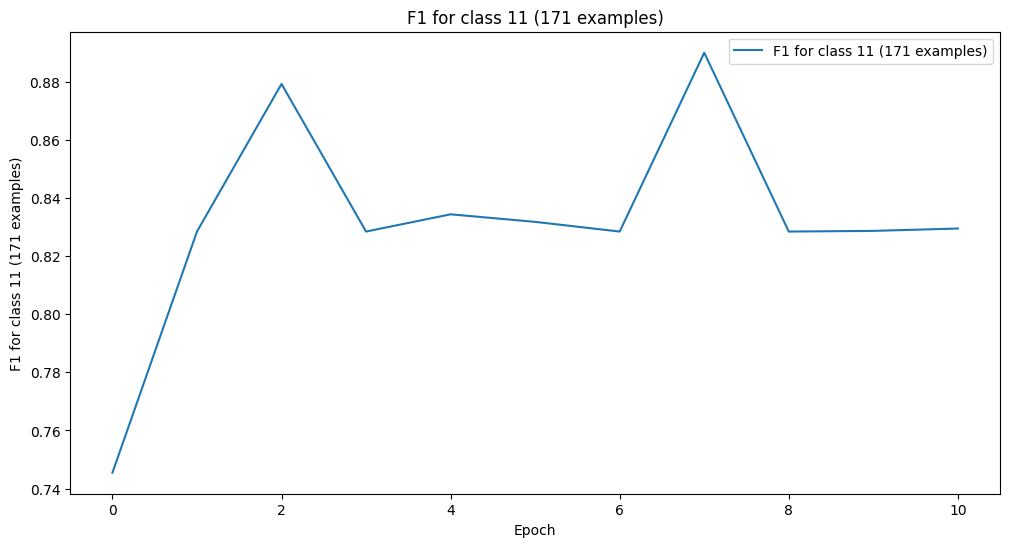

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

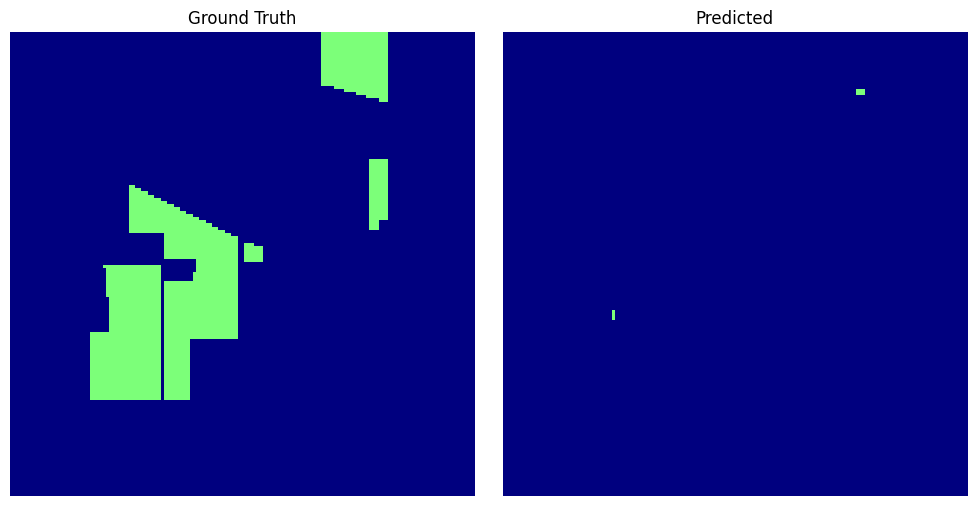

 39%|███▉      | 7/18 [10:22<16:15, 88.68s/it, id=171, val_average_accuracy=0.884, val_f1=0.83, val_kappa=0.00646, val_loss=0.101, val_overall_accuracy=0.502]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |          | 0/? [00:00<?, ?it/s]

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy       0.883614718914032
         val_f1             0.8293972611427307
        val_kappa          0.005742013454437256
        val_loss            0.08923901617527008
  val_overall_accuracy      0.5016293525695801
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


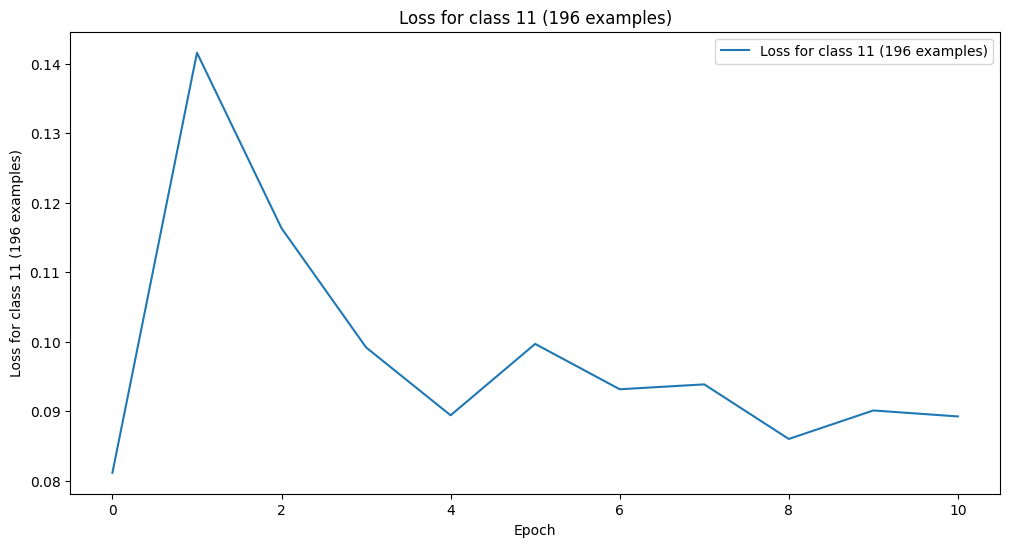

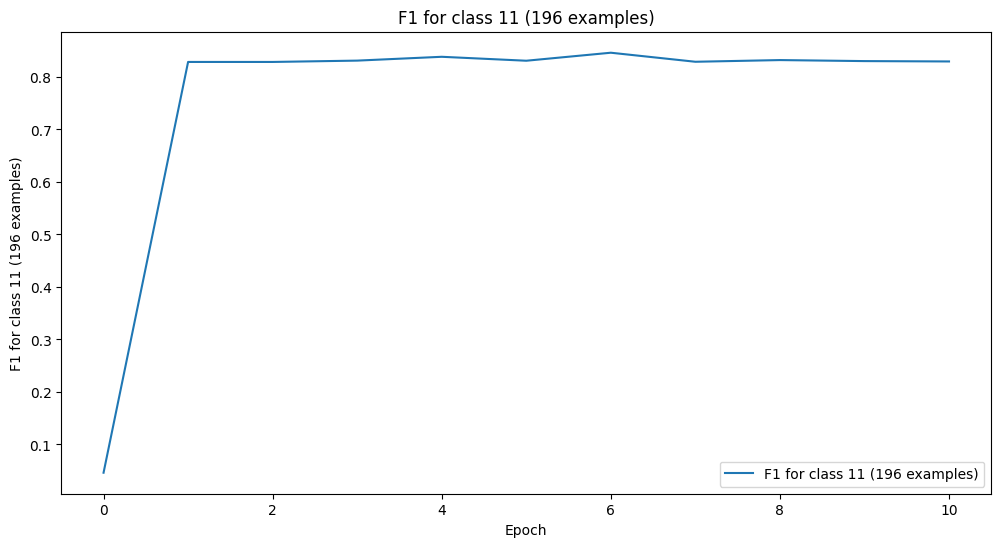

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

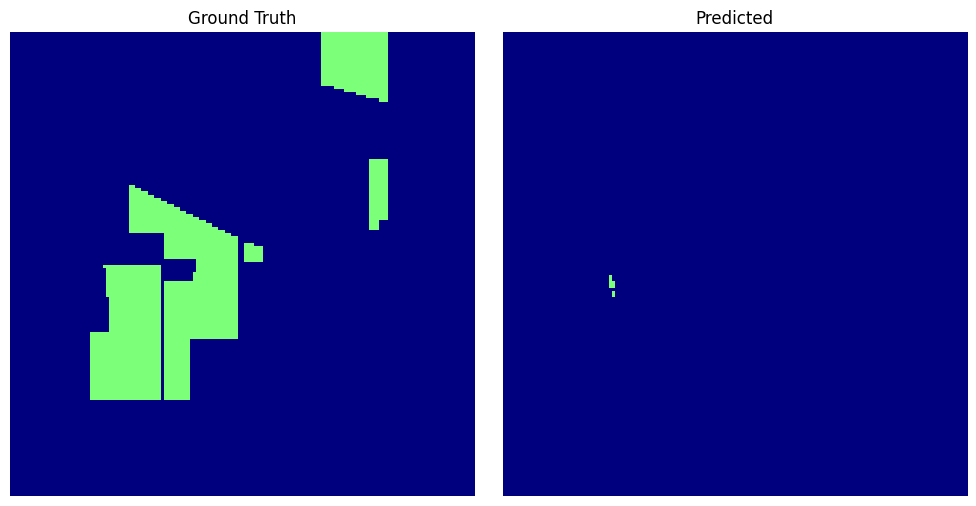

 44%|████▍     | 8/18 [11:49<14:41, 88.19s/it, id=196, val_average_accuracy=0.884, val_f1=0.829, val_kappa=0.00574, val_loss=0.0892, val_overall_accuracy=0.502]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |          | 0/? [00:00<?, ?it/s]

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy       0.883804976940155
         val_f1             0.8298583626747131
        val_kappa          0.008602321147918701
        val_loss            0.09502240270376205
  val_overall_accuracy      0.5024439692497253
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


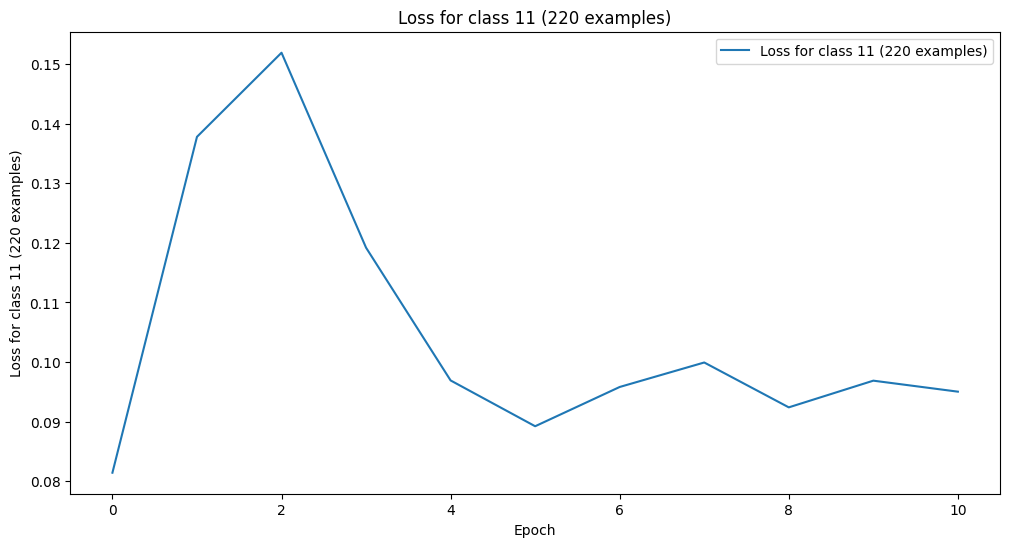

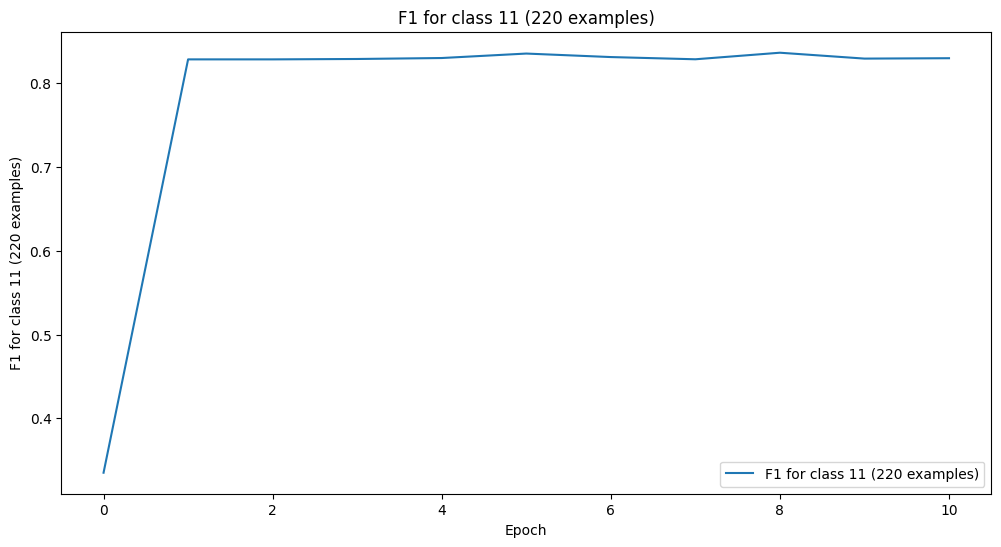

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

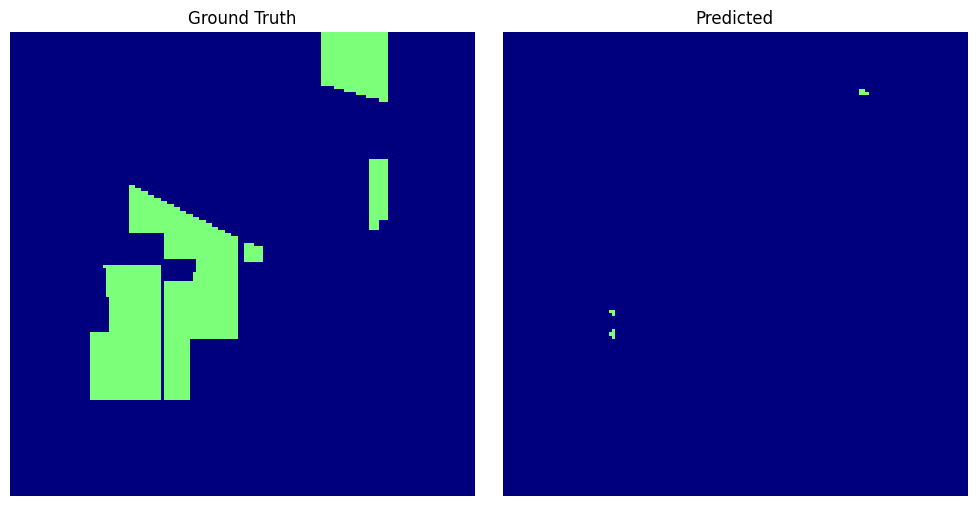

 50%|█████     | 9/18 [13:16<13:10, 87.85s/it, id=220, val_average_accuracy=0.884, val_f1=0.83, val_kappa=0.0086, val_loss=0.095, val_overall_accuracy=0.502]   You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |          | 0/? [00:00<?, ?it/s]

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.8993103504180908
         val_f1             0.8642296195030212
        val_kappa           0.2226240038871765
        val_loss            0.08858901262283325
  val_overall_accuracy      0.5698995590209961
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


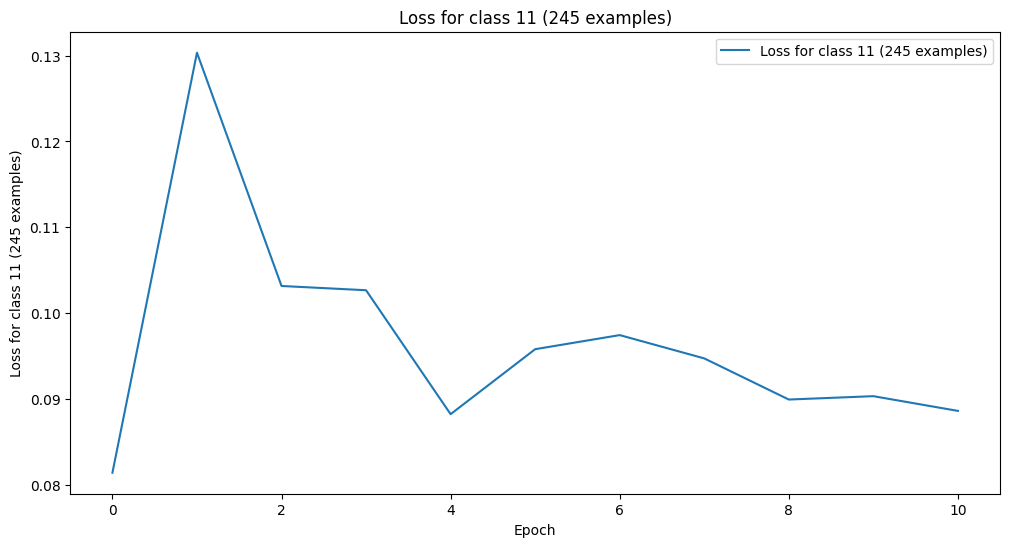

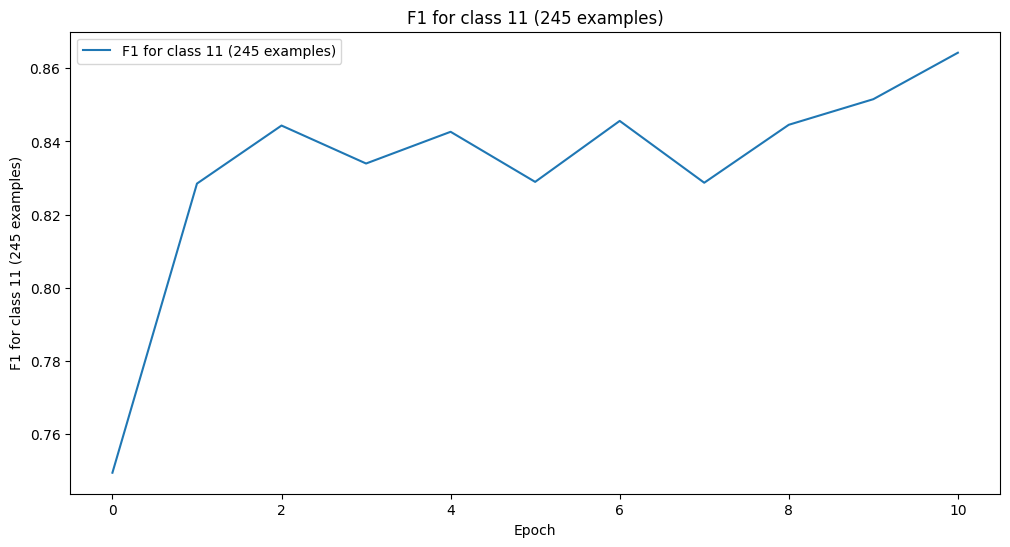

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

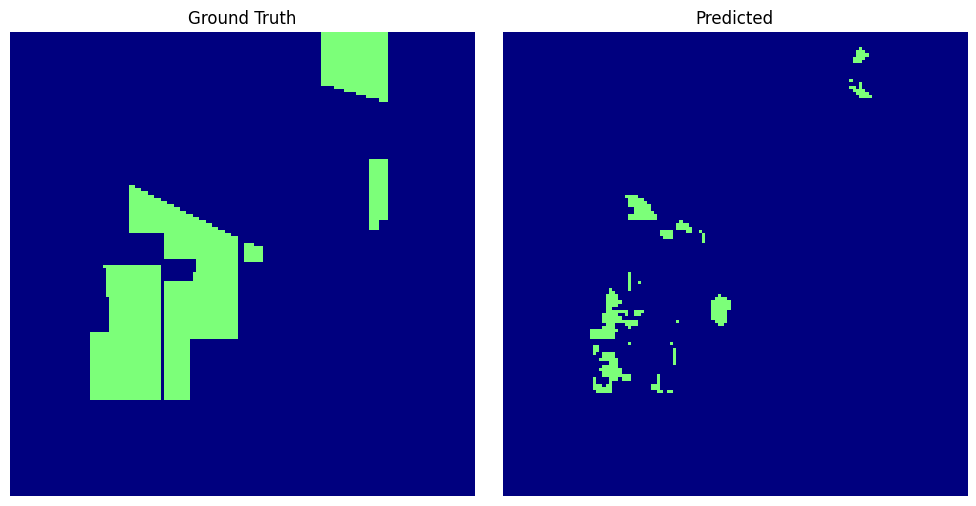

 56%|█████▌    | 10/18 [14:50<11:56, 89.59s/it, id=245, val_average_accuracy=0.899, val_f1=0.864, val_kappa=0.223, val_loss=0.0886, val_overall_accuracy=0.57]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |          | 0/? [00:00<?, ?it/s]

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.9671343564987183
         val_f1             0.9651119112968445
        val_kappa           0.8217954039573669
        val_loss            0.07832125574350357
  val_overall_accuracy       0.867396891117096
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


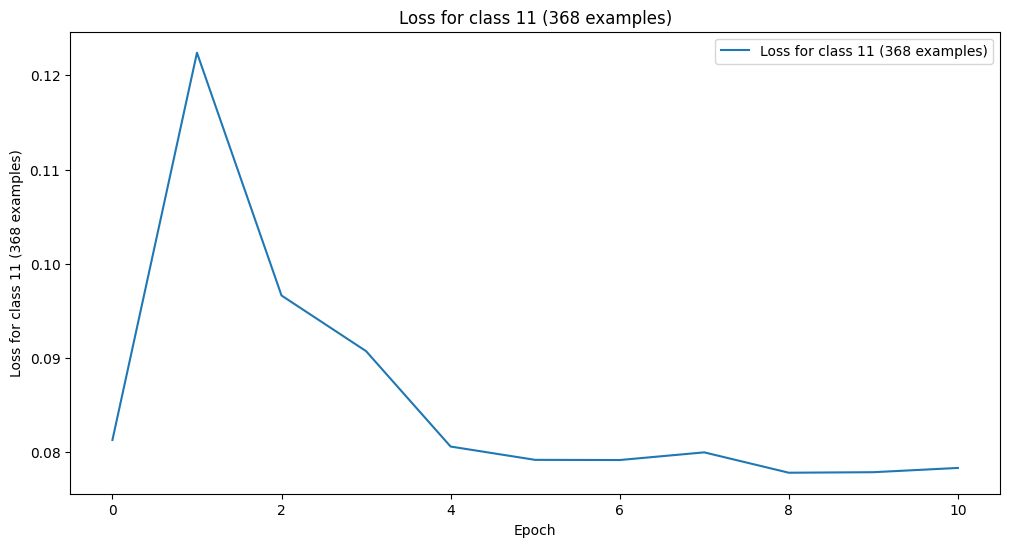

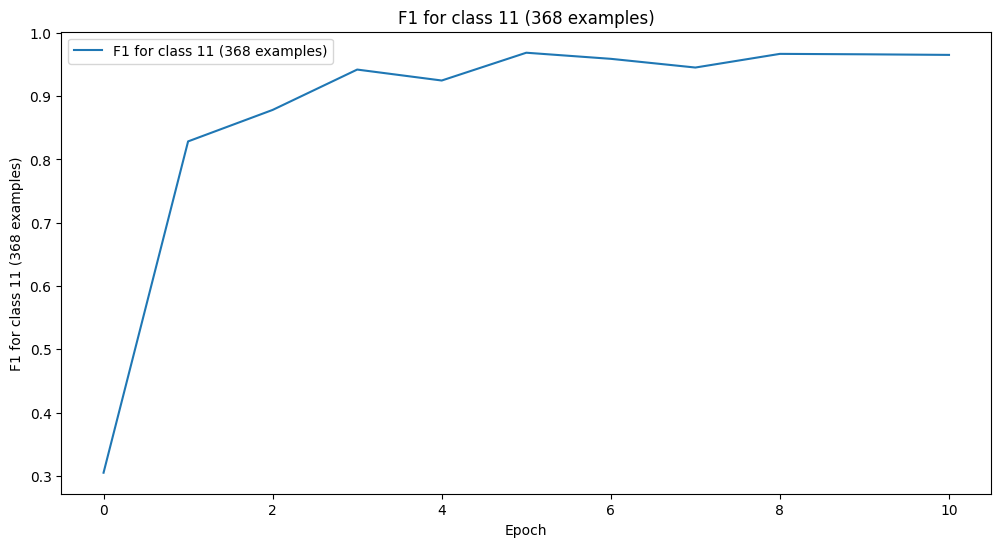

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

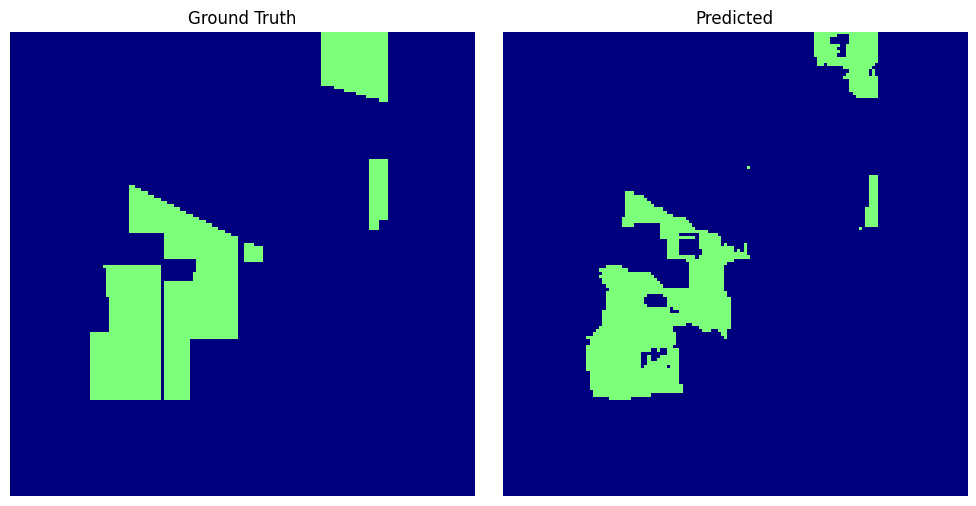

 61%|██████    | 11/18 [16:19<10:25, 89.31s/it, id=368, val_average_accuracy=0.967, val_f1=0.965, val_kappa=0.822, val_loss=0.0783, val_overall_accuracy=0.867]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.9835909605026245
         val_f1             0.9836154580116272
        val_kappa           0.9206843376159668
        val_loss            0.07879572361707687
  val_overall_accuracy      0.9617253541946411
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


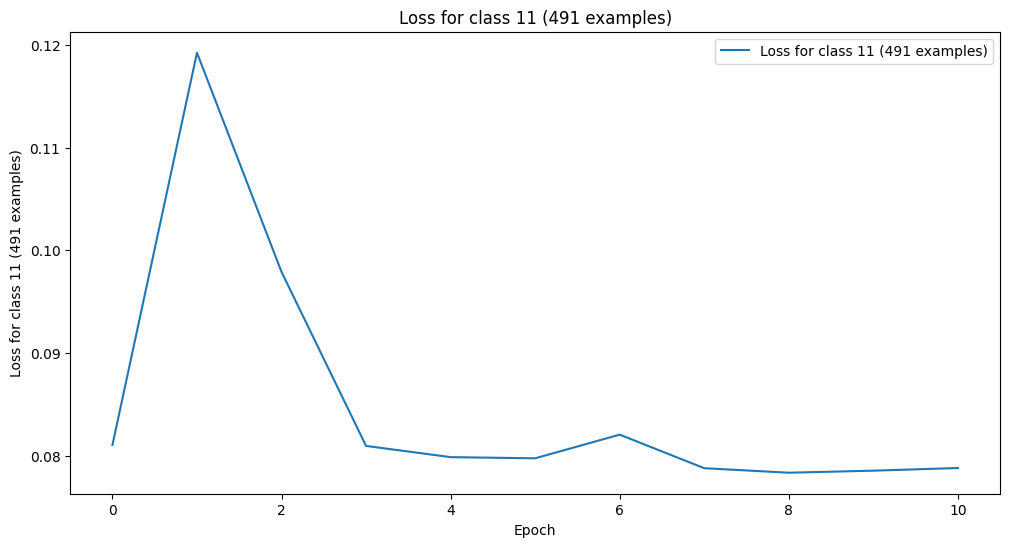

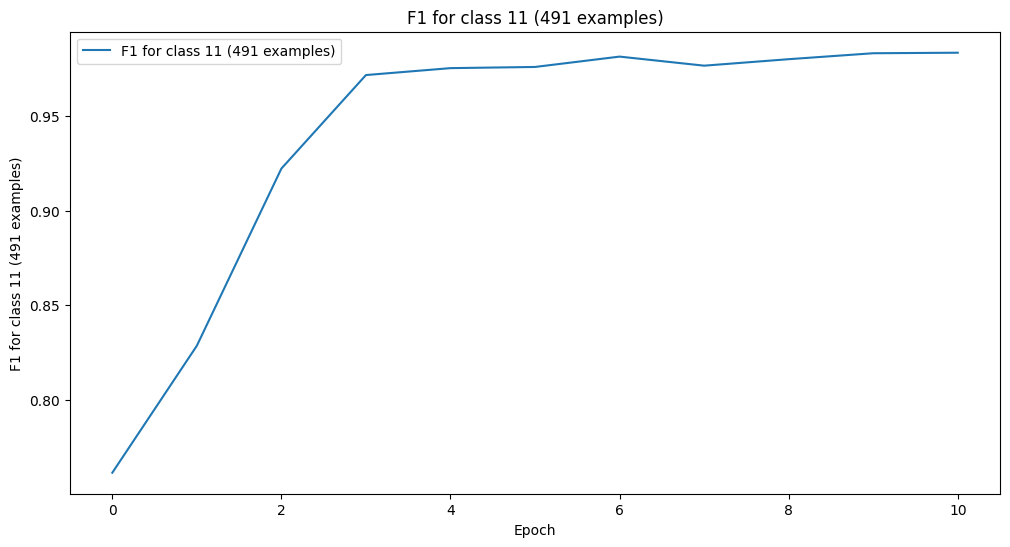

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

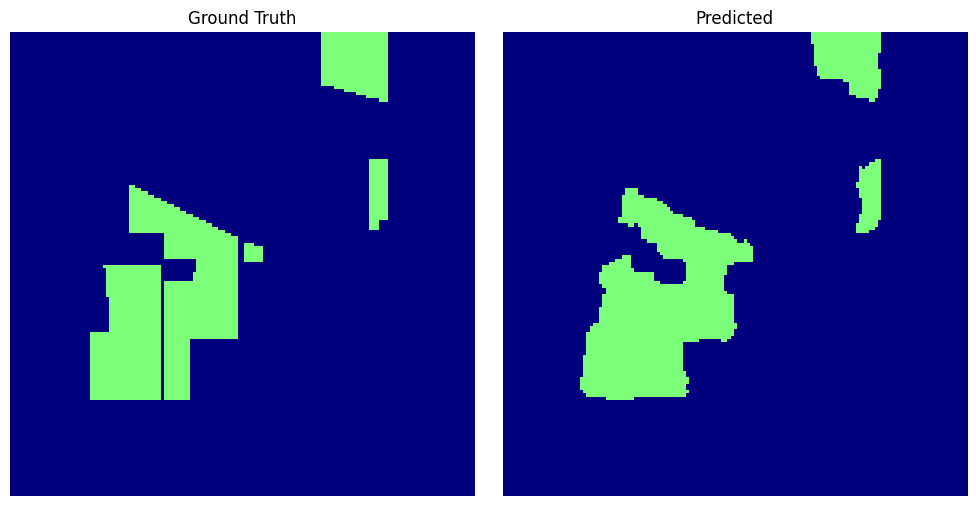

 67%|██████▋   | 12/18 [17:47<08:53, 88.89s/it, id=491, val_average_accuracy=0.984, val_f1=0.984, val_kappa=0.921, val_loss=0.0788, val_overall_accuracy=0.962]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.9805945158004761
         val_f1             0.9810323119163513
        val_kappa           0.9102341532707214
        val_loss            0.08161900192499161
  val_overall_accuracy      0.9769961833953857
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


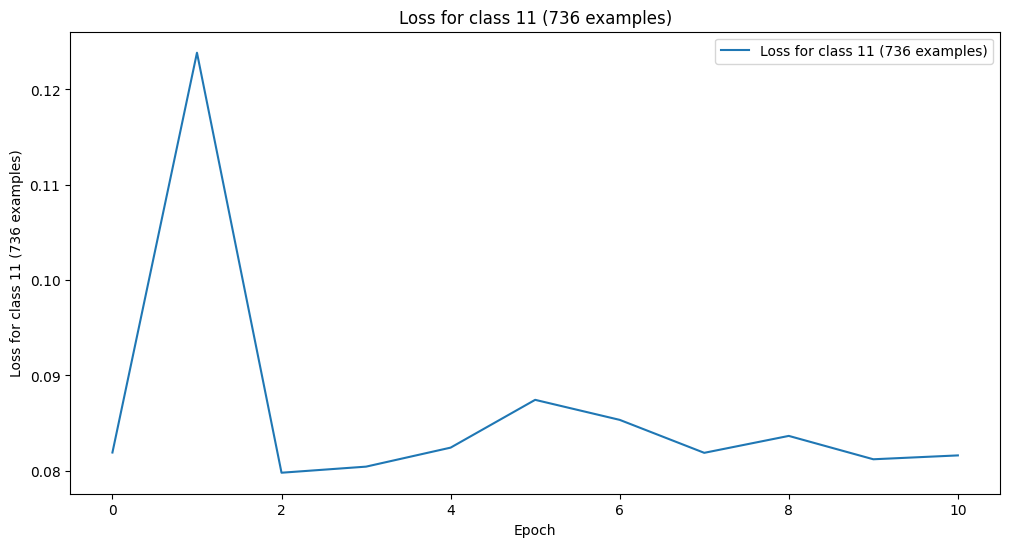

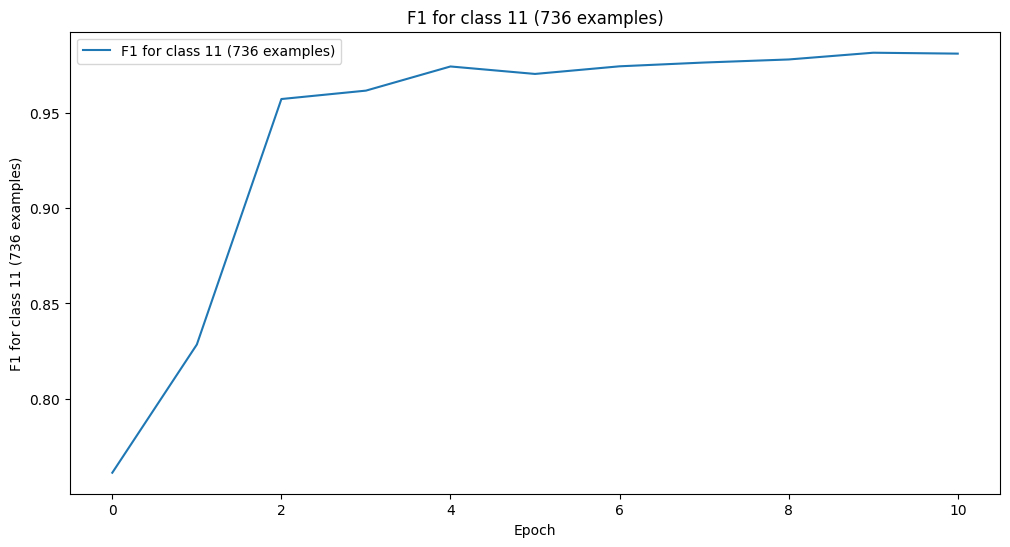

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

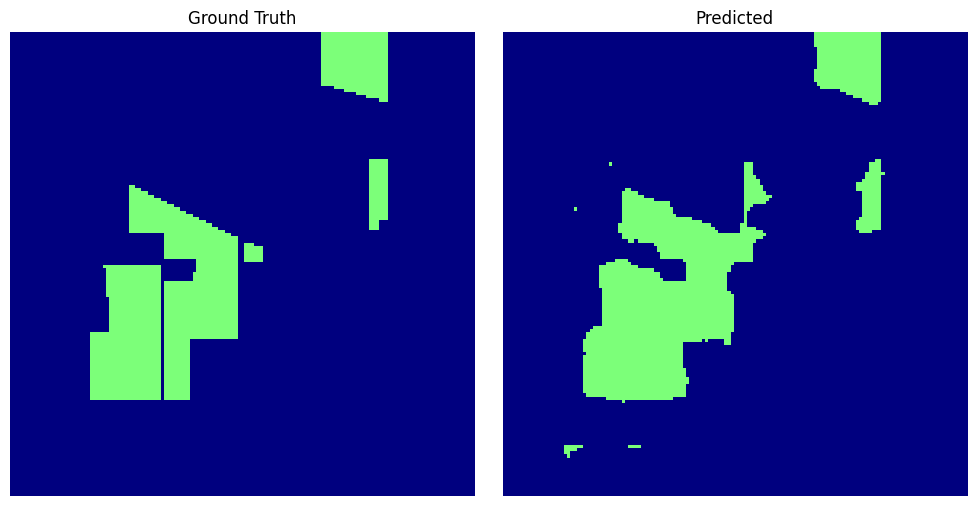

 72%|███████▏  | 13/18 [19:14<07:22, 88.58s/it, id=736, val_average_accuracy=0.981, val_f1=0.981, val_kappa=0.91, val_loss=0.0816, val_overall_accuracy=0.977] You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |          | 0/? [00:00<?, ?it/s]

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.9667062759399414
         val_f1             0.9684165716171265
        val_kappa           0.8558586835861206
        val_loss            0.08913848549127579
  val_overall_accuracy       0.97920823097229
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


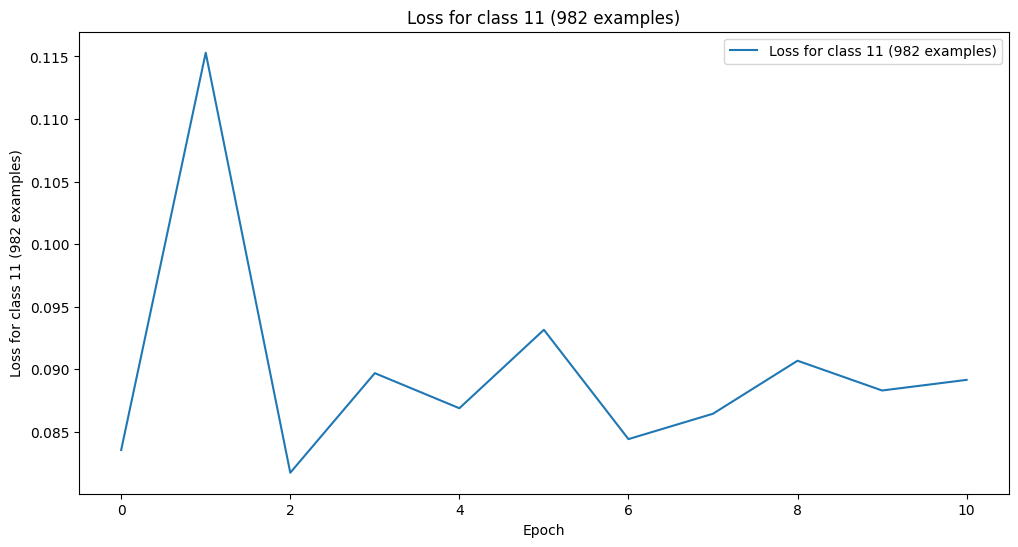

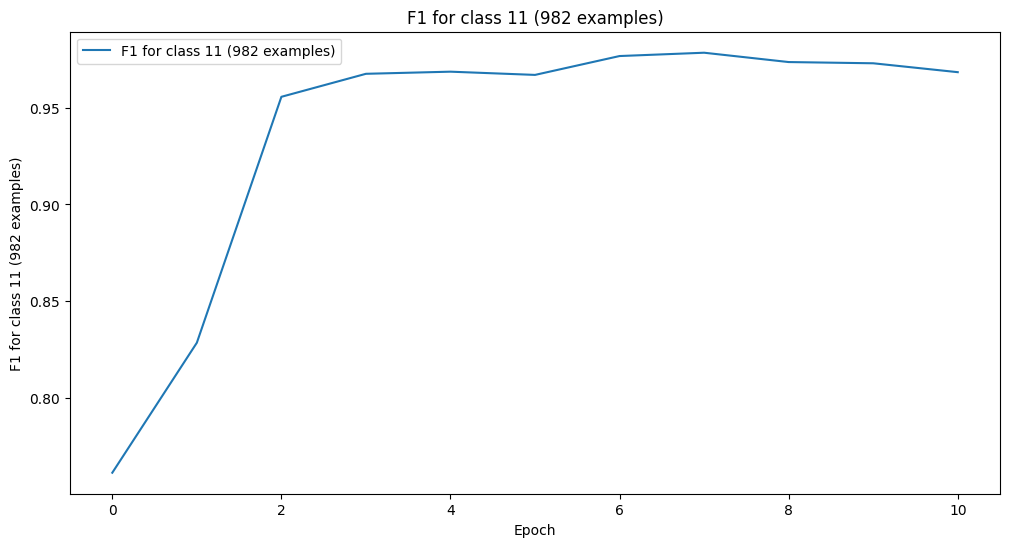

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

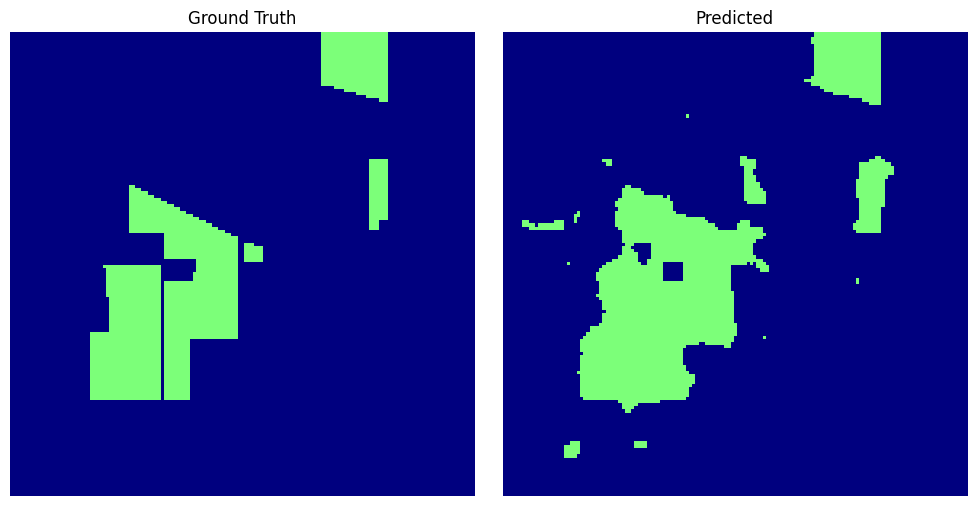

 78%|███████▊  | 14/18 [20:46<05:57, 89.43s/it, id=982, val_average_accuracy=0.967, val_f1=0.968, val_kappa=0.856, val_loss=0.0891, val_overall_accuracy=0.979]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.9537217617034912
         val_f1             0.9568946957588196
        val_kappa           0.8082099556922913
        val_loss            0.09540907293558121
  val_overall_accuracy      0.9727413654327393
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


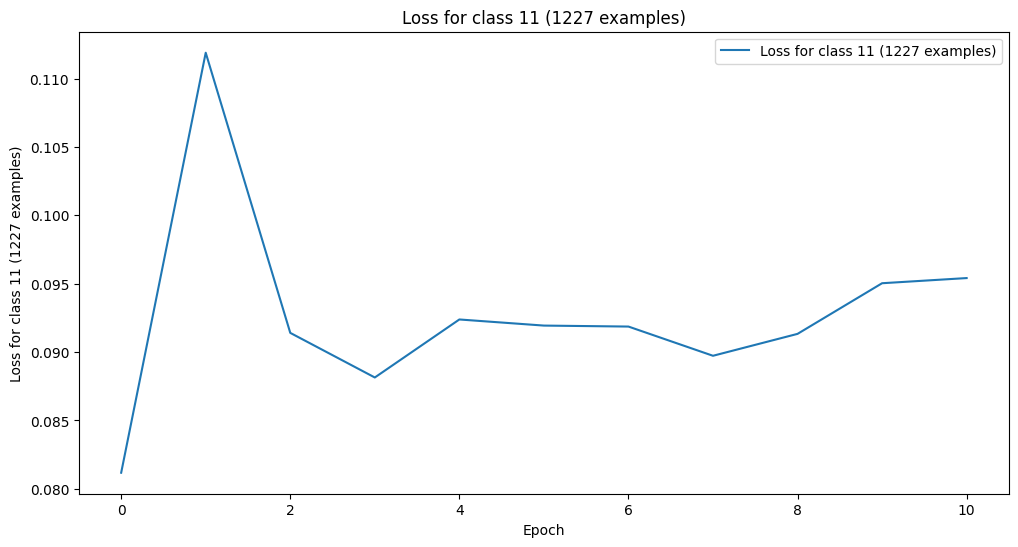

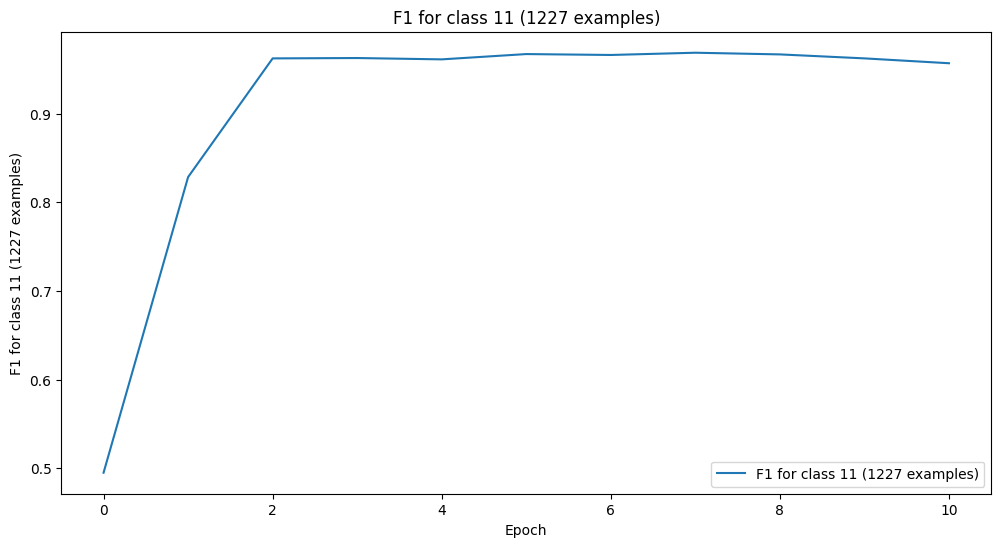

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

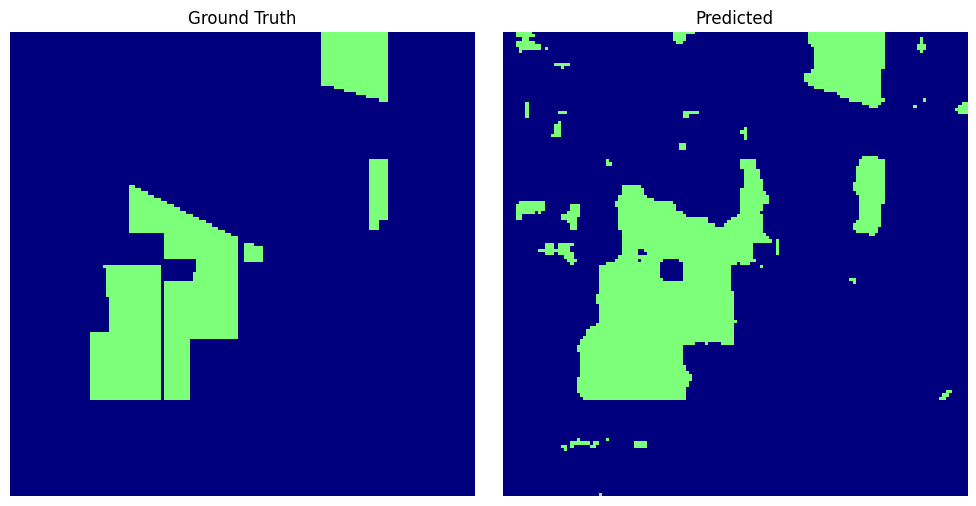

 83%|████████▎ | 15/18 [22:16<04:29, 89.74s/it, id=1227, val_average_accuracy=0.954, val_f1=0.957, val_kappa=0.808, val_loss=0.0954, val_overall_accuracy=0.973]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |          | 0/? [00:00<?, ?it/s]

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.9493460059165955
         val_f1             0.9530906081199646
        val_kappa           0.7930768132209778
        val_loss            0.09611748158931732
  val_overall_accuracy      0.9706177711486816
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


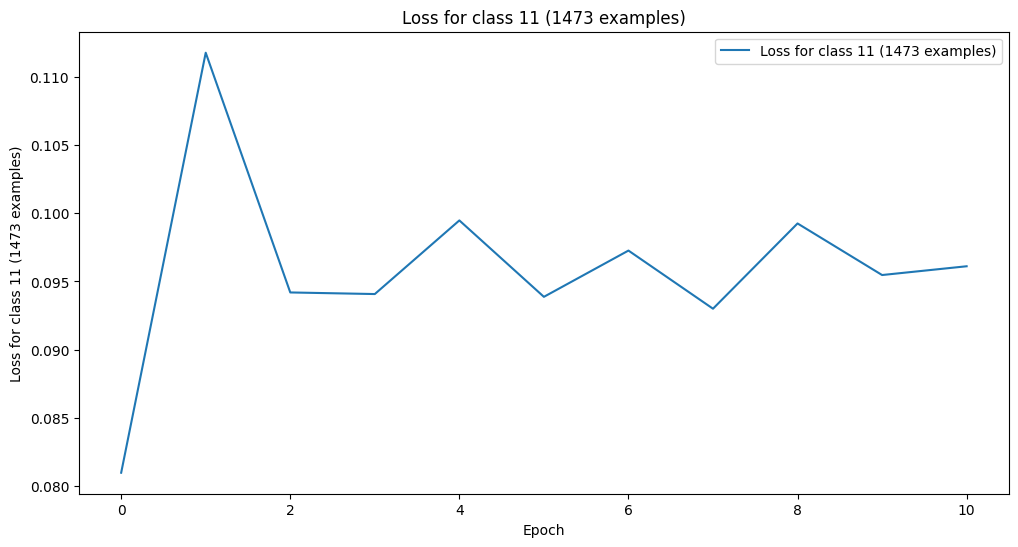

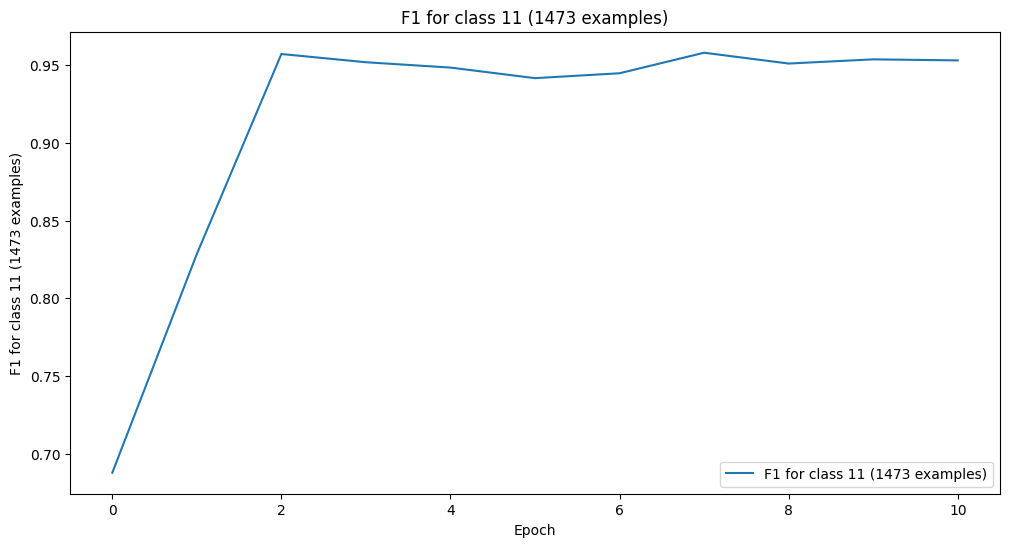

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

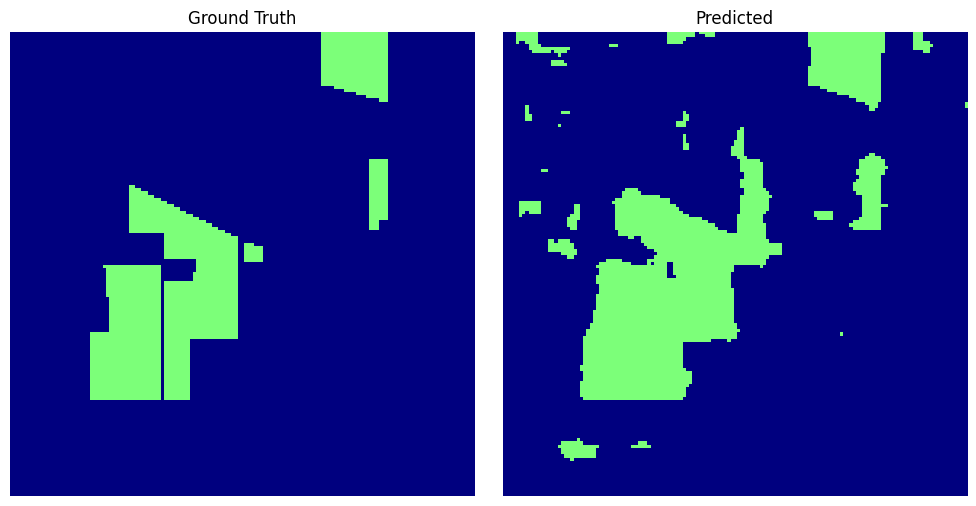

 89%|████████▉ | 16/18 [23:44<02:58, 89.11s/it, id=1473, val_average_accuracy=0.949, val_f1=0.953, val_kappa=0.793, val_loss=0.0961, val_overall_accuracy=0.971]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |          | 0/? [00:00<?, ?it/s]

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.9347919225692749
         val_f1             0.9405964612960815
        val_kappa           0.7447962760925293
        val_loss            0.09970828890800476
  val_overall_accuracy      0.9613182544708252
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


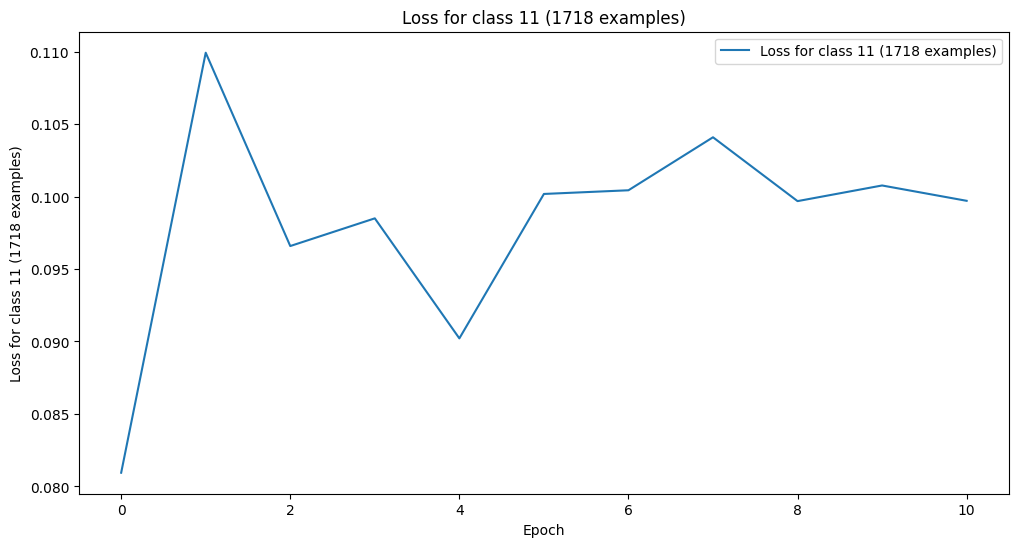

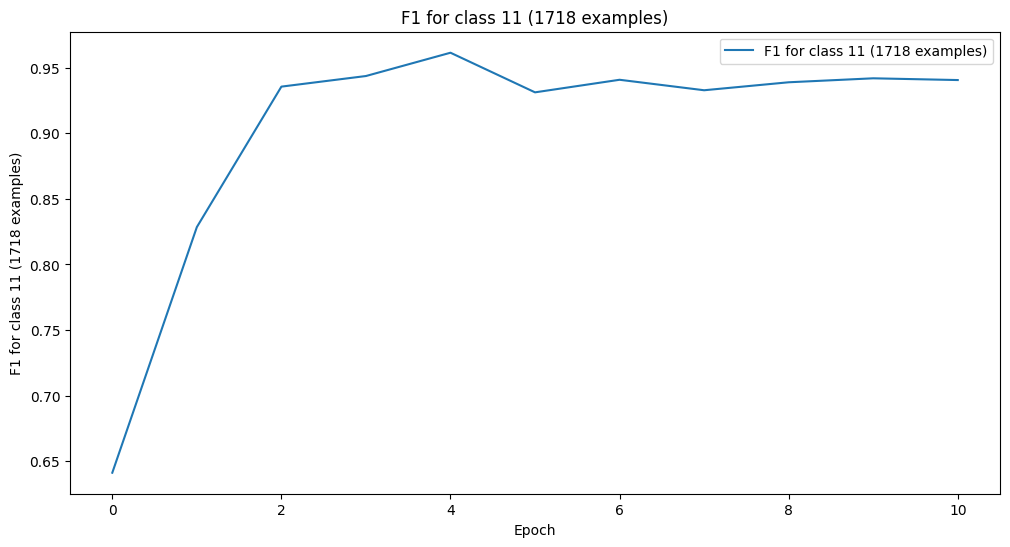

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

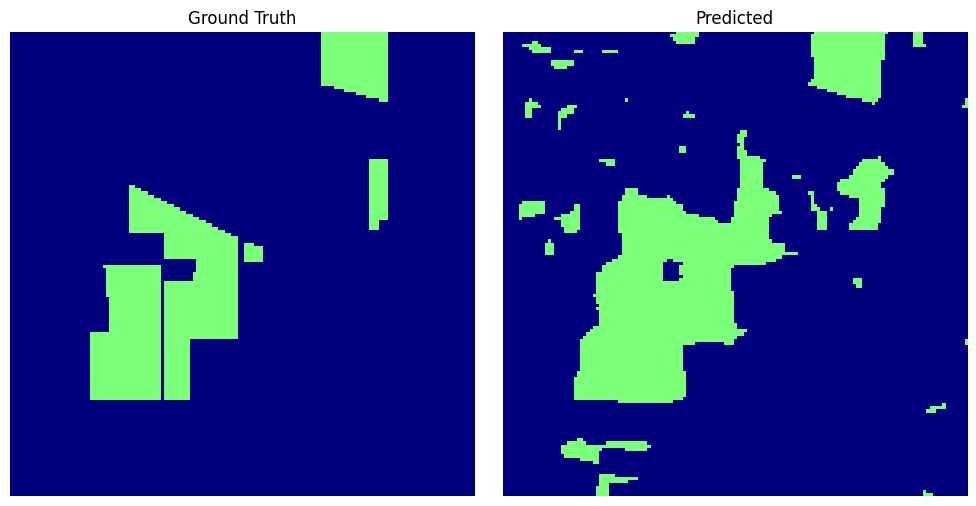

 94%|█████████▍| 17/18 [25:14<01:29, 89.25s/it, id=1718, val_average_accuracy=0.935, val_f1=0.941, val_kappa=0.745, val_loss=0.0997, val_overall_accuracy=0.961]You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |          | 0/? [00:00<?, ?it/s]

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  val_average_accuracy      0.9112960696220398
         val_f1             0.9211259484291077
        val_kappa           0.6761298179626465
        val_loss            0.10431081056594849
  val_overall_accuracy      0.9489009380340576
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


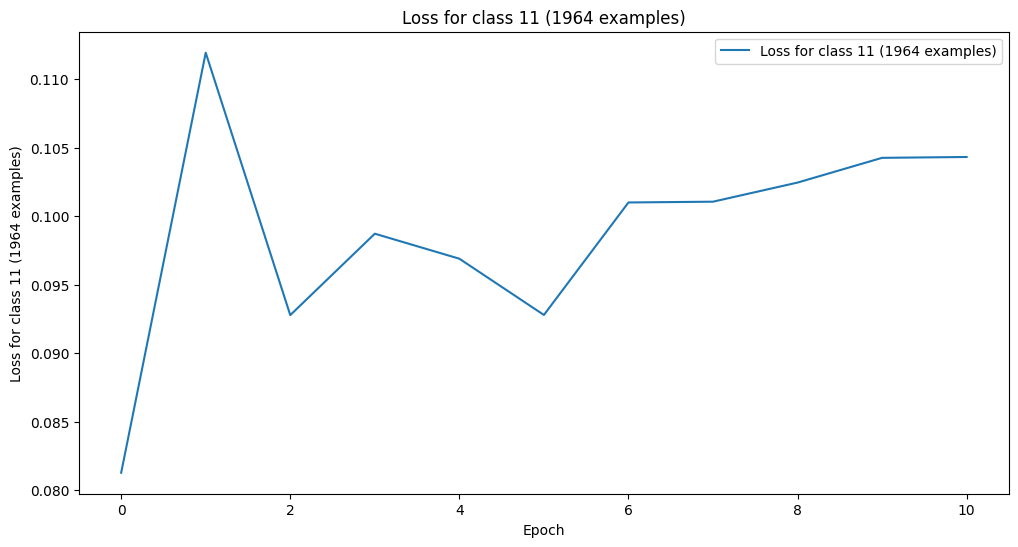

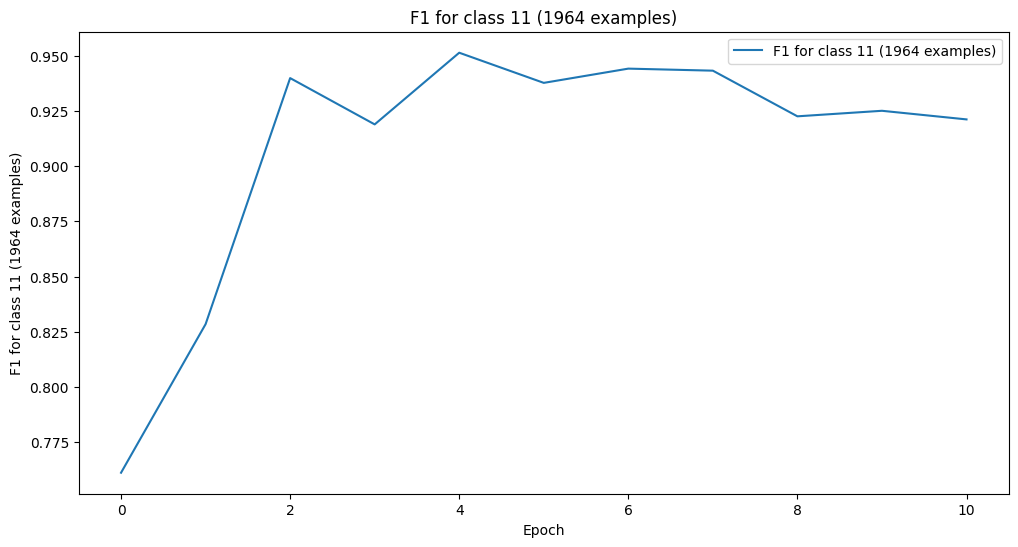

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

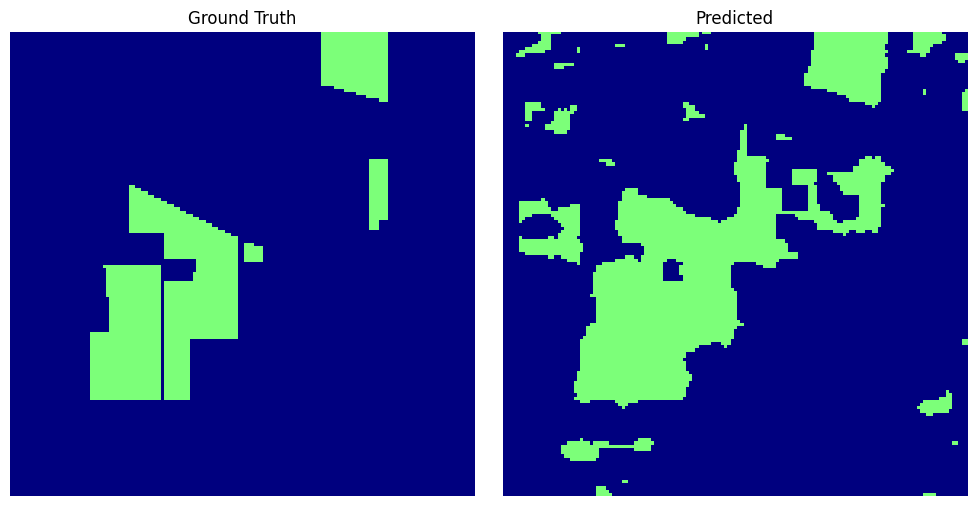

100%|██████████| 18/18 [26:41<00:00, 88.97s/it, id=1964, val_average_accuracy=0.911, val_f1=0.921, val_kappa=0.676, val_loss=0.104, val_overall_accuracy=0.949] 


In [38]:
search = RepresentativeDataPointsSearch(
    IndianPinesDatapointsSearch(target_class), log_dir, f"class-{target_class}"
)

feedback = search.run()

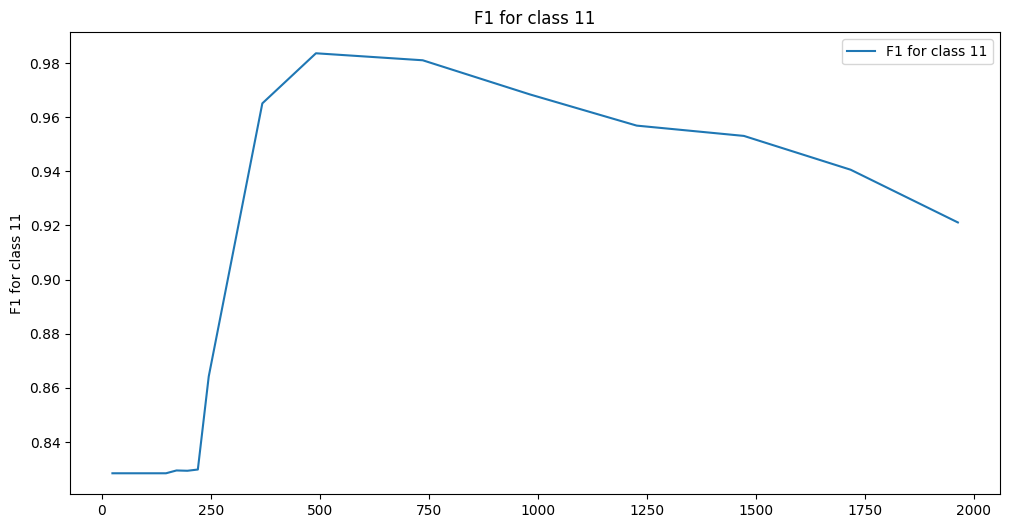

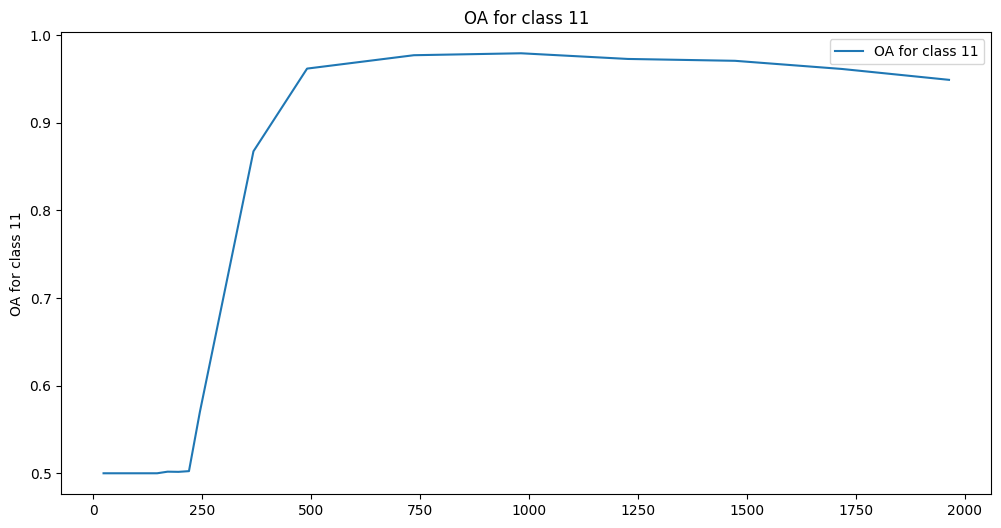

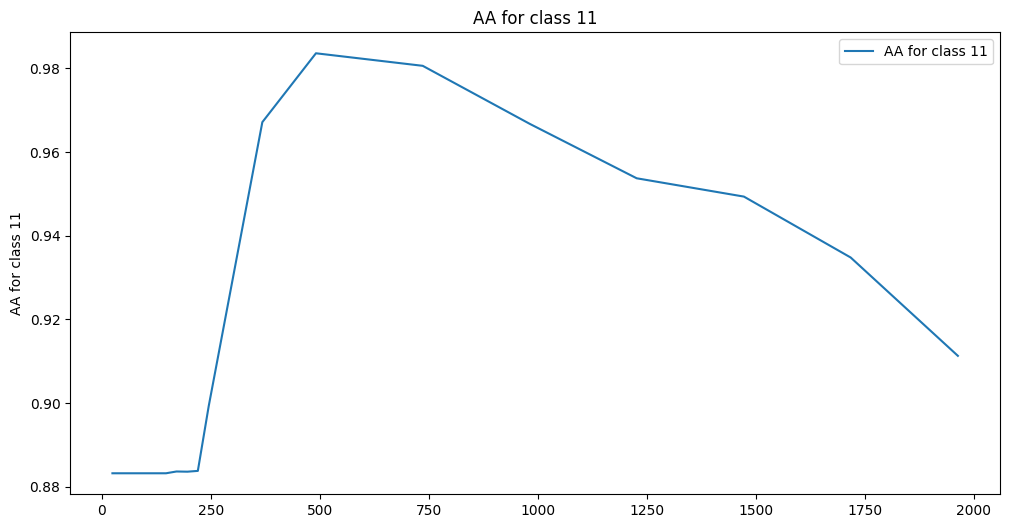

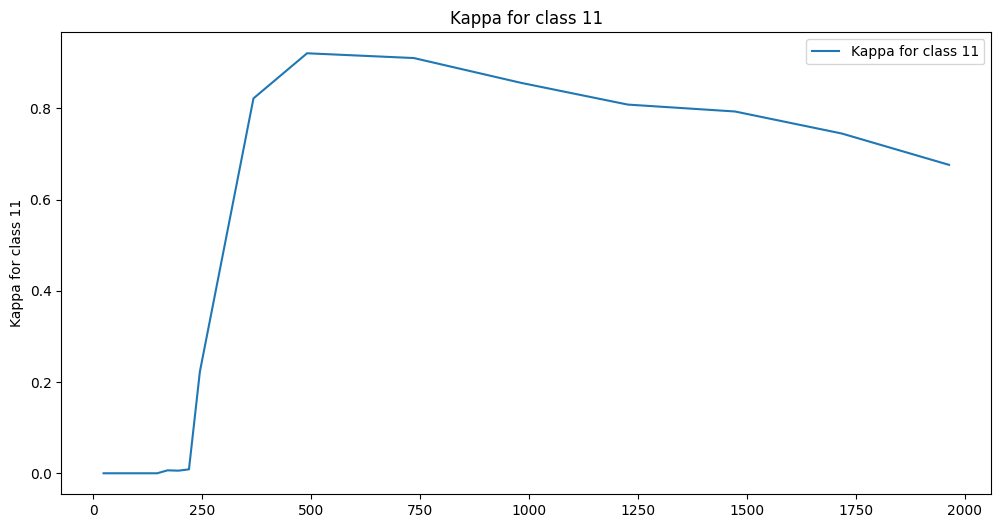

In [39]:
ids = [int(it.id) for it in feedback]
f1s = [it.score["val_f1"] for it in feedback]
oas = [it.score["val_overall_accuracy"] for it in feedback]
aas = [it.score["val_average_accuracy"] for it in feedback]
kappas = [it.score["val_kappa"] for it in feedback]

plot_generic(ids, f1s, desc=f"F1 for class {target_class}")
plot_generic(ids, oas, desc=f"OA for class {target_class}")
plot_generic(ids, aas, desc=f"AA for class {target_class}")
plot_generic(ids, kappas, desc=f"Kappa for class {target_class}")